In [1]:
import matplotlib.pyplot as plt
import matplotlib

import os
import pandas as pd
import numpy as np

In [2]:
df_mean_dict = dict()
df_std_dict = dict()
for file in os.listdir("./results/processed_results_memory"):
    if ".csv" not in file: continue
    df = pd.read_csv("./results/processed_results_memory/" + file, index_col = 0)
    suffix_order = {
        '5_edges': 0,
        '10_edges': 1,
        '20_edges': 2,
        'scale_free': 3
    }
    
    def sorting_key(name):
        name_str = str(name)
        
        if name_str == 'ppi':
            return (0, 0)
        if 'SBC' in name_str:
            return (1, 0)
        
        if '_nodes_' in name_str:
            parts = name_str.split('_nodes_')
            try:
                node_count = int(parts[0])
                suffix = parts[1]
                return (node_count, suffix_order.get(suffix, 99))
            except (ValueError, IndexError):
                return (float('inf'), 99)
                
        return (float('inf'), 99)
    
    df['temp_sort'] = df['name'].apply(sorting_key)
    df = df.sort_values('temp_sort').drop(columns='temp_sort').reset_index(drop=True)
    df["name"] = df["name"].replace("1015074_nodes_SBC", "SBC")
    if "mean" in file:
        df_mean_dict[file] = df
    if "std" in file:
        df_std_dict[file] = df

In [3]:
df_mean_dict.keys()

dict_keys(['postgres_list_mean.csv', 'neo4jee_col_mean.csv', 'sqlite_col_mean.csv', 'postgres_col_mean.csv', 'sqlite_list_mean.csv', 'mysql_col_mean.csv', 'neo4jce_list_mean.csv', 'neo4jce_col_mean.csv', 'mysql_list_mean.csv', 'neo4jee_list_mean.csv'])

In [4]:
df_mean_dict['mysql_list_mean.csv']

,name,create,delete,read_1,read_2,read_3,update_edges,update_nodes
0,ppi,0.008003,0.004739,4.351376,15.051176,29.039945,18.720940,0.693287
1,SBC,0.007840,0.004837,15.496849,16.168167,16.168009,60.715431,15.497009
2,1000_nodes_5_edges,0.007855,0.004723,0.087749,0.204210,0.821329,0.084343,0.040240
3,1000_nodes_10_edges,0.007851,0.004704,0.107982,0.610906,5.022521,0.160637,0.040422
4,1000_nodes_20_edges,0.007855,0.004713,0.173473,1.914664,9.939007,0.313225,0.040361
5,1000_nodes_scale_free,0.007869,0.004704,2.027569,5.917147,6.543049,0.058517,0.040778
6,10000_nodes_5_edges,0.007832,0.004704,0.262326,0.763710,1.006646,0.770988,0.160664
7,10000_nodes_10_edges,0.007833,0.004707,0.460265,1.436221,11.338779,1.533928,0.160669
8,10000_nodes_20_edges,0.007833,0.004734,0.862721,3.152411,288.515004,3.059807,0.160685
9,10000_nodes_scale_free,0.007834,0.004704,13.054391,341.041262,482.482655,0.281502,0.160797


In [5]:
def get_headers(df_dict):
    for key in df_dict:
        df_data = df_dict[key].iloc[:, 1:]
        return df_data.columns

In [6]:
def get_index(df_dict):
    for key in df_dict:
        df_names = df_dict[key].loc[:, "name"]
        return df_names

In [7]:
def get_header_dict(df_dict):
    header_dfs_dict = dict()
    for header in get_headers(df_dict):
        header_dfs_dict[header] = pd.DataFrame(index = get_index(df_dict))
    for key in df_dict:
        experiment_name = "_".join(key.split("_")[-3:-1])
        df_names = df_dict[key].loc[:, "name"]
        df_data = df_dict[key].drop(columns=["name"])
        header = df_data.columns
        for column in header:
            if "_json" in key: ## sqlite_list_json  -> sqlite_json
                experiment_name = "_".join(key.split("_")[-4:-2])
            header_dfs_dict[column][experiment_name] = df_data[column].values
    return header_dfs_dict

In [8]:
header_dfs_dict = get_header_dict(df_mean_dict)
header_dfs_dict["create"]

,postgres_list,neo4jee_col,sqlite_col,postgres_col,sqlite_list,mysql_col,neo4jce_list,neo4jce_col,mysql_list,neo4jee_list
name,,,,,,,,,,
ppi,0.039204,0.045596,0.054301,0.039201,0.054319,0.011570,0.029101,0.107755,0.008003,0.030461
SBC,0.038792,0.030022,0.054511,0.039180,0.054526,0.007839,0.031083,0.031432,0.007840,0.030389
1000_nodes_5_edges,0.052173,0.036421,0.054421,0.052218,0.054426,0.007852,0.030548,0.037626,0.007855,0.029810
1000_nodes_10_edges,0.052123,0.036939,0.054423,0.052114,0.054435,0.007852,0.030567,0.037401,0.007851,0.030211
1000_nodes_20_edges,0.053002,0.036939,0.054423,0.052993,0.054434,0.007856,0.030897,0.038074,0.007855,0.030316
1000_nodes_scale_free,0.039052,0.036429,0.054437,0.039014,0.054452,0.007856,0.030563,0.037271,0.007869,0.029801
10000_nodes_5_edges,0.053188,0.036939,0.054423,0.053309,0.054438,0.007831,0.031219,0.037270,0.007832,0.029852
10000_nodes_10_edges,0.053285,0.036427,0.054430,0.053342,0.054445,0.007832,0.031204,0.038009,0.007833,0.030421
10000_nodes_20_edges,0.053263,0.036650,0.054430,0.053371,0.054440,0.007832,0.030804,0.037992,0.007833,0.030525


In [9]:
header_dfs_std_dict = get_header_dict(df_std_dict)

In [10]:
header_dfs_std_dict["create"]

,postgres_list,neo4jee_list,mysql_col,postgres_col,neo4jce_list,neo4jee_col,neo4jce_col,mysql_list,sqlite_col,sqlite_list
name,,,,,,,,,,
ppi,0.000062,0.000435,0.019887,0.000048,0.001600,0.000000,0.137820,0.000035,0.000000,0.000047
SBC,0.000129,0.000314,0.000024,0.000072,0.000372,0.000163,0.000768,0.000026,0.000000,0.000029
1000_nodes_5_edges,0.000064,0.000249,0.000054,0.000041,0.000238,0.000234,0.000433,0.000049,0.000026,0.000017
1000_nodes_10_edges,0.000070,0.000258,0.000051,0.000039,0.000256,0.000000,0.000455,0.000043,0.000000,0.000010
1000_nodes_20_edges,0.000059,0.000024,0.000053,0.000070,0.000307,0.000000,0.000836,0.000049,0.000000,0.000008
1000_nodes_scale_free,0.000040,0.000238,0.000048,0.000055,0.000238,0.000234,0.000471,0.000055,0.000000,0.000027
10000_nodes_5_edges,0.000127,0.000239,0.000000,0.000091,0.000093,0.000000,0.000485,0.000000,0.000000,0.000027
10000_nodes_10_edges,0.000113,0.000091,0.000000,0.000069,0.000146,0.000234,0.000686,0.000000,0.000000,0.000027
10000_nodes_20_edges,0.000112,0.000113,0.000000,0.000074,0.000315,0.000242,0.000648,0.000000,0.000000,0.000002


In [11]:
header_dfs_dict["read_3"].max()

postgres_list     2887.056686
neo4jee_col       4016.453346
sqlite_col        5526.626616
postgres_col      2887.057439
sqlite_list       3568.068079
mysql_col         3345.093483
neo4jce_list     11876.726911
neo4jce_col       4016.453517
mysql_list        3345.091518
neo4jee_list     11876.727009
dtype: float64

In [12]:
for key in header_dfs_dict:
    print(key)
    print(header_dfs_dict[key].max(0))
    print(header_dfs_std_dict[key].max(0))
    #print(header_dfs_dict[key])
    
    print(30*"_")

create
postgres_list    0.053651
neo4jee_col      0.045596
sqlite_col       0.054511
postgres_col     0.053857
sqlite_list      0.054526
mysql_col        0.011570
neo4jce_list     0.031329
neo4jce_col      0.107755
mysql_list       0.008003
neo4jee_list     0.030568
dtype: float64
postgres_list    0.000178
neo4jee_list     0.000435
mysql_col        0.019887
postgres_col     0.000118
neo4jce_list     0.001600
neo4jee_col      0.000242
neo4jce_col      0.137820
mysql_list       0.000055
sqlite_col       0.000026
sqlite_list      0.000047
dtype: float64
______________________________
delete
postgres_list    0.002221
neo4jee_col      0.018643
sqlite_col       0.000697
postgres_col     0.002137
sqlite_list      0.000704
mysql_col        0.004836
neo4jce_list     0.019253
neo4jce_col      0.030027
mysql_list       0.004857
neo4jee_list     0.018643
dtype: float64
postgres_list    0.000640
neo4jee_list     0.001654
mysql_col        0.000250
postgres_col     0.000456
neo4jce_list     0.001787


In [13]:
header_dfs_dict["update_edges"].max(0)

postgres_list    76.302317
neo4jee_col      76.301994
sqlite_col       76.301994
postgres_col     76.302381
sqlite_list      76.301994
mysql_col        76.301994
neo4jce_list     76.301994
neo4jce_col      76.301994
mysql_list       76.301994
neo4jee_list     76.301994
dtype: float64

In [14]:
def sort_and_filter_df(df, filter_key):
    df = df.sort_index(axis=1)
    df = df.loc[:, list(filter(lambda col: filter_key in col, df.columns))]
    return df

In [15]:
font = {'family' : 'arial',
        'weight' : 'normal',
        'size'   : 16}

db_colors = {
    "neo4jce": "lightblue",
    "neo4jee": "darkblue",
    "postgres": "orange",
    "mysql": "red",
    "in_mem": "black",
    "sqlite": "purple"
}

matplotlib.rc('font', **font)

def plot_crud_operations(header_dfs_dict, header_dfs_std_dict, filter_key = "col", log_scale = True):
    for key in header_dfs_dict:
        if "in_mem" in key: continue
        df = header_dfs_dict[key]
        df_std = header_dfs_std_dict[key]
        df = sort_and_filter_df(df, filter_key)
        df_std = sort_and_filter_df(df_std, filter_key)        
        num_cols = len(df.columns)
        print(num_cols)
        x = np.arange(len(df))  # x-axis positions
        width = 0.8 / num_cols  # Adjust bar width to avoid excessive overlap
    
        fig, ax = plt.subplots(figsize=(26, 4))
        
        for i, col in enumerate(df.columns):
            color = db_colors[list(filter(lambda key: key in col, db_colors))[0]]
            db_label = " ".join(col.split("_")[0:-1])
            ax.bar(x + i * width, df[col], width=width, label=db_label, color = color, yerr = df_std[col])
    
        if log_scale:
            ax.set_yscale('log')  # Log-scale base 10
        filter_key_title_dict = {
            "col": "(Columns)",
            "list": "(List)",
        }
        title = key
        if "read" in title.lower():
            title = title.replace("_", "- subgraph depth ")
        title = title.replace("_", " ")
        ax.set_title(title.title() + " "+ filter_key_title_dict[filter_key])
        ax.set_xticks(x + width * (num_cols / 2 - 0.5))  # Center xticks

        def process_dataset_label(label:str):
            return label.replace("nodes", "N\n").replace("edges", "E").replace("scale_free", "SF").replace("_", "")[::-1].replace("000", "000,")[::-1]
        print(df.index)
        dataset_label = list(map(process_dataset_label, df.index))
        ax.set_xticklabels(dataset_label) #, rotation=90
        sec = ax.secondary_xaxis(location=0)
        sec.set_xticks([.8, 3.8, 7.8,  11.8, 14.8], labels=['\n\nReal-world', '\n\nSmall', '\n\nMedium', '\n\nLarge', '\n\nLargest'])
        sec.tick_params('x', length=0)
        sec2 = ax.secondary_xaxis(location=0)
        sec2.set_xticks([-.3, 1.8, 5.7, 9.8, 13.8], labels=[])
        sec2.tick_params('x', length=40, width=1.5)
        ax.legend()
        ax.grid(which = "both", axis = "y")
        ax.grid(which = "major", axis = "x")
        plt.ylabel("Time [s]")
        plt.xlabel("\nDataset")
        plt.show()

5
Index(['ppi', 'SBC', '1000_nodes_5_edges', '1000_nodes_10_edges',
       '1000_nodes_20_edges', '1000_nodes_scale_free', '10000_nodes_5_edges',
       '10000_nodes_10_edges', '10000_nodes_20_edges',
       '10000_nodes_scale_free', '100000_nodes_5_edges',
       '100000_nodes_10_edges', '100000_nodes_20_edges',
       '100000_nodes_scale_free', '1000000_nodes_5_edges',
       '1000000_nodes_scale_free'],
      dtype='object', name='name')


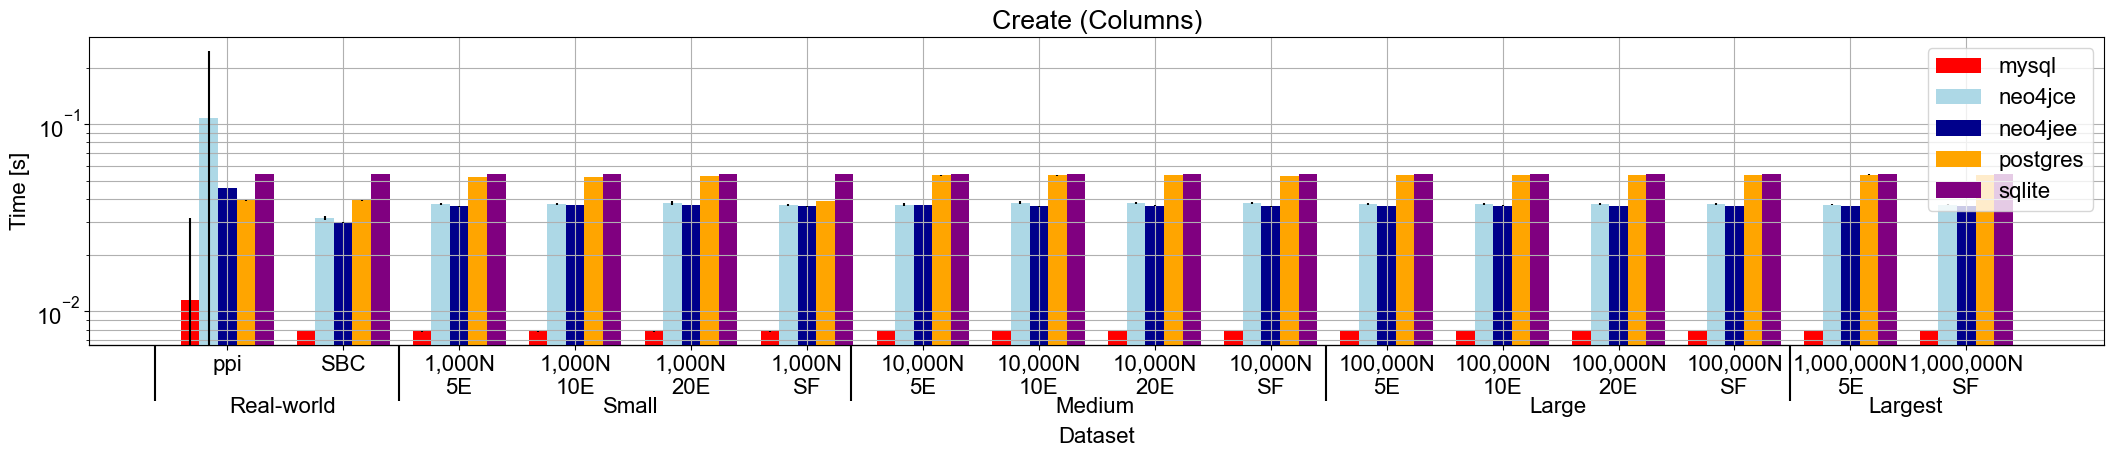

5
Index(['ppi', 'SBC', '1000_nodes_5_edges', '1000_nodes_10_edges',
       '1000_nodes_20_edges', '1000_nodes_scale_free', '10000_nodes_5_edges',
       '10000_nodes_10_edges', '10000_nodes_20_edges',
       '10000_nodes_scale_free', '100000_nodes_5_edges',
       '100000_nodes_10_edges', '100000_nodes_20_edges',
       '100000_nodes_scale_free', '1000000_nodes_5_edges',
       '1000000_nodes_scale_free'],
      dtype='object', name='name')


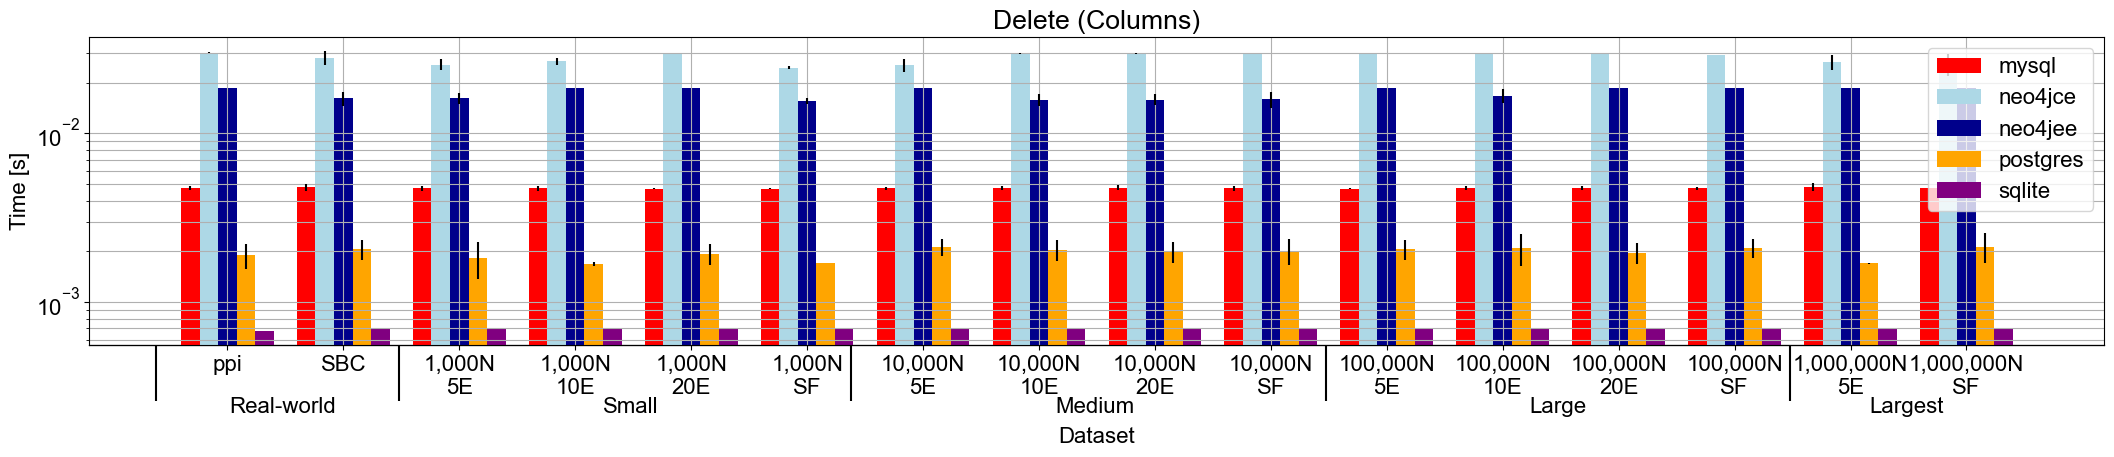

5
Index(['ppi', 'SBC', '1000_nodes_5_edges', '1000_nodes_10_edges',
       '1000_nodes_20_edges', '1000_nodes_scale_free', '10000_nodes_5_edges',
       '10000_nodes_10_edges', '10000_nodes_20_edges',
       '10000_nodes_scale_free', '100000_nodes_5_edges',
       '100000_nodes_10_edges', '100000_nodes_20_edges',
       '100000_nodes_scale_free', '1000000_nodes_5_edges',
       '1000000_nodes_scale_free'],
      dtype='object', name='name')


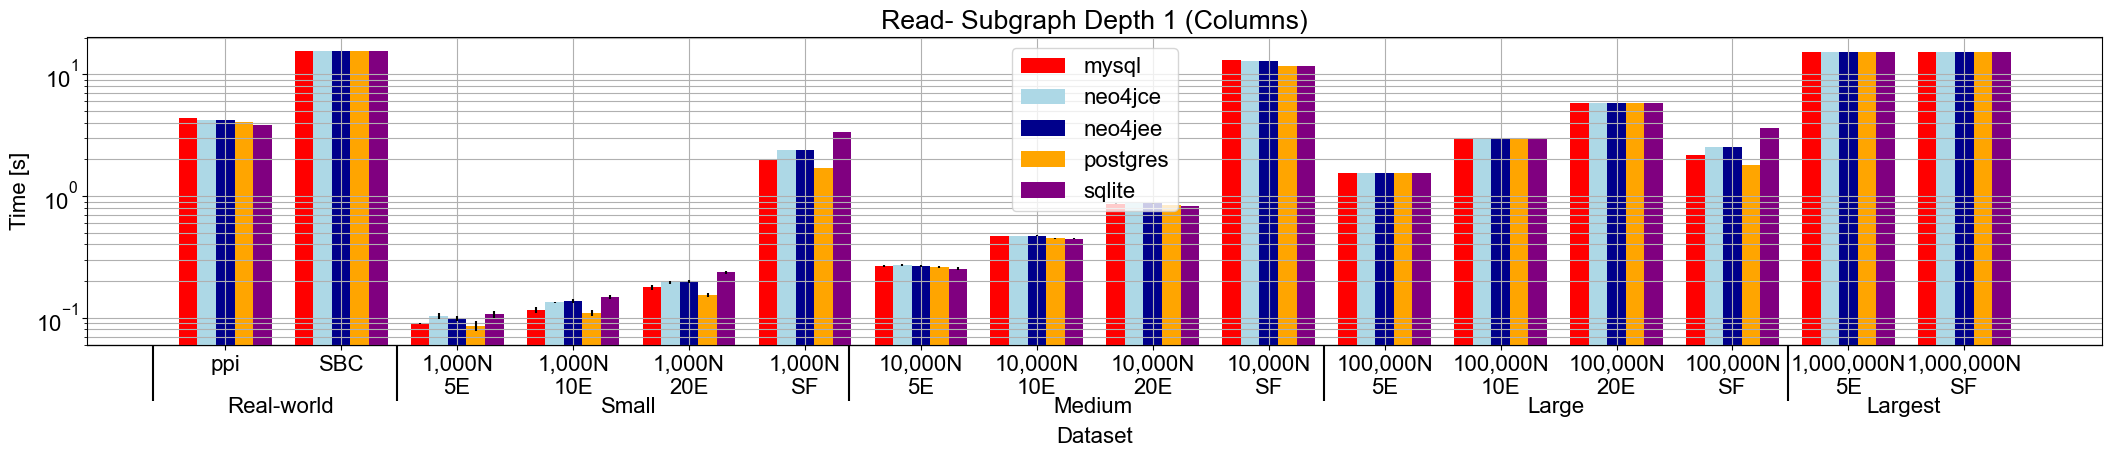

5
Index(['ppi', 'SBC', '1000_nodes_5_edges', '1000_nodes_10_edges',
       '1000_nodes_20_edges', '1000_nodes_scale_free', '10000_nodes_5_edges',
       '10000_nodes_10_edges', '10000_nodes_20_edges',
       '10000_nodes_scale_free', '100000_nodes_5_edges',
       '100000_nodes_10_edges', '100000_nodes_20_edges',
       '100000_nodes_scale_free', '1000000_nodes_5_edges',
       '1000000_nodes_scale_free'],
      dtype='object', name='name')


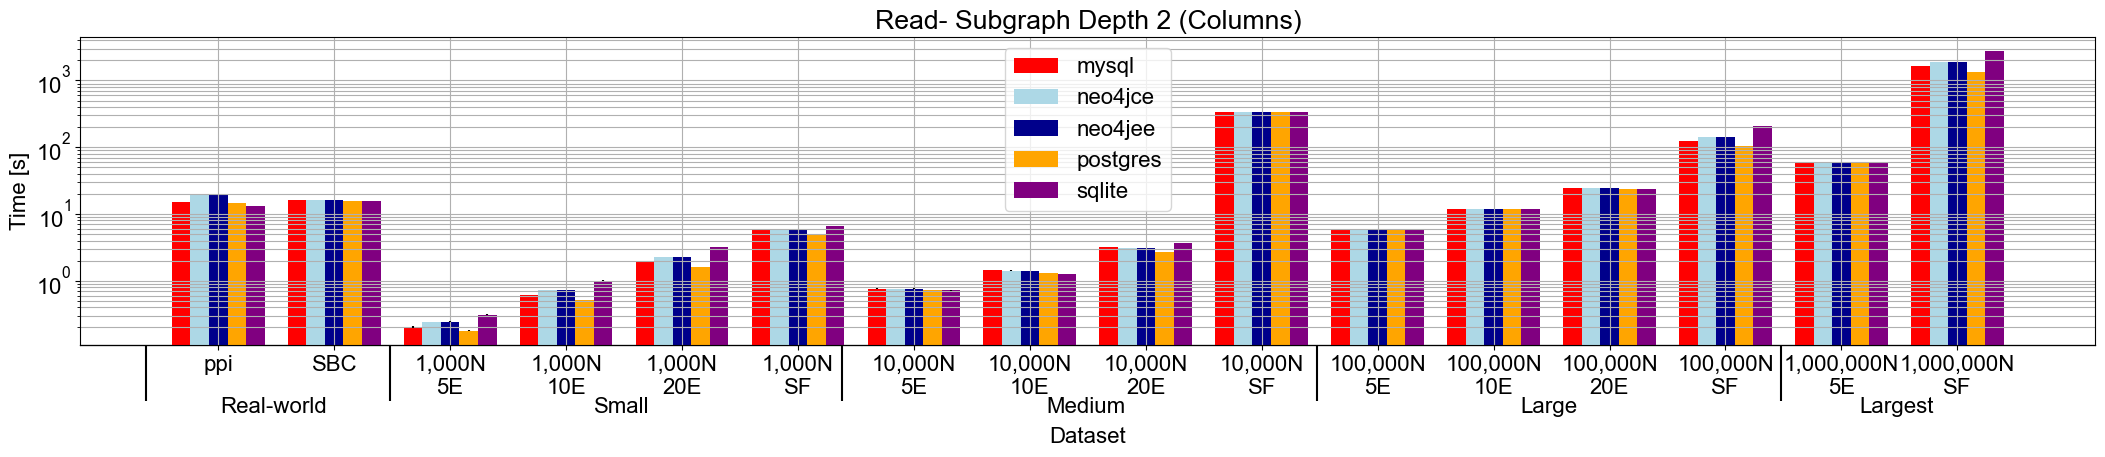

5
Index(['ppi', 'SBC', '1000_nodes_5_edges', '1000_nodes_10_edges',
       '1000_nodes_20_edges', '1000_nodes_scale_free', '10000_nodes_5_edges',
       '10000_nodes_10_edges', '10000_nodes_20_edges',
       '10000_nodes_scale_free', '100000_nodes_5_edges',
       '100000_nodes_10_edges', '100000_nodes_20_edges',
       '100000_nodes_scale_free', '1000000_nodes_5_edges',
       '1000000_nodes_scale_free'],
      dtype='object', name='name')


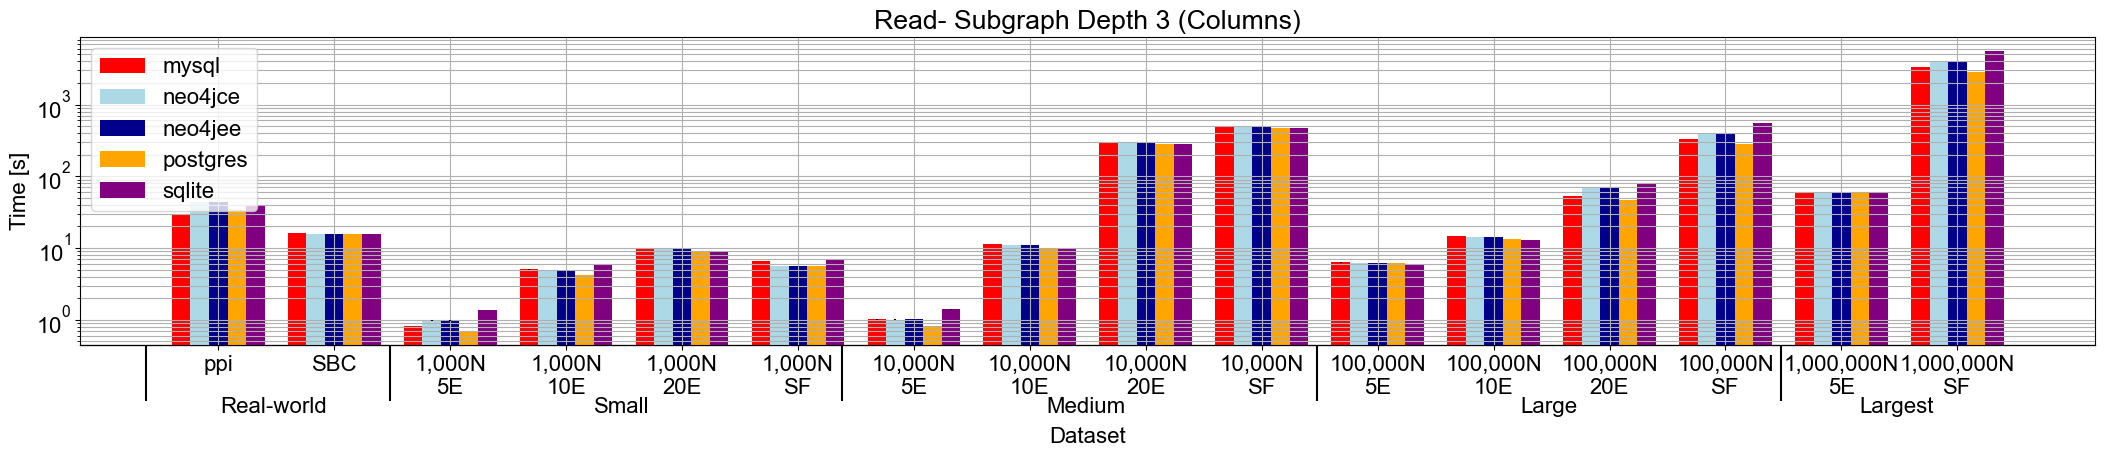

5
Index(['ppi', 'SBC', '1000_nodes_5_edges', '1000_nodes_10_edges',
       '1000_nodes_20_edges', '1000_nodes_scale_free', '10000_nodes_5_edges',
       '10000_nodes_10_edges', '10000_nodes_20_edges',
       '10000_nodes_scale_free', '100000_nodes_5_edges',
       '100000_nodes_10_edges', '100000_nodes_20_edges',
       '100000_nodes_scale_free', '1000000_nodes_5_edges',
       '1000000_nodes_scale_free'],
      dtype='object', name='name')


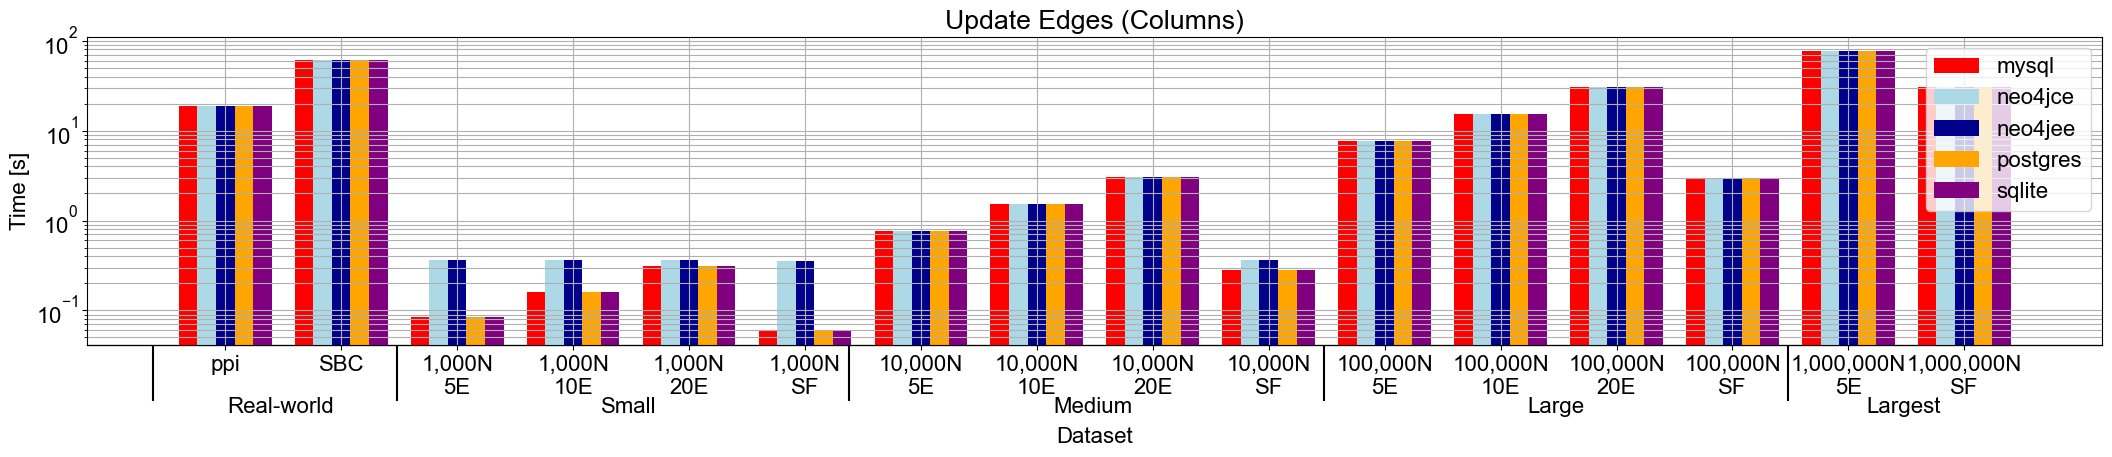

5
Index(['ppi', 'SBC', '1000_nodes_5_edges', '1000_nodes_10_edges',
       '1000_nodes_20_edges', '1000_nodes_scale_free', '10000_nodes_5_edges',
       '10000_nodes_10_edges', '10000_nodes_20_edges',
       '10000_nodes_scale_free', '100000_nodes_5_edges',
       '100000_nodes_10_edges', '100000_nodes_20_edges',
       '100000_nodes_scale_free', '1000000_nodes_5_edges',
       '1000000_nodes_scale_free'],
      dtype='object', name='name')


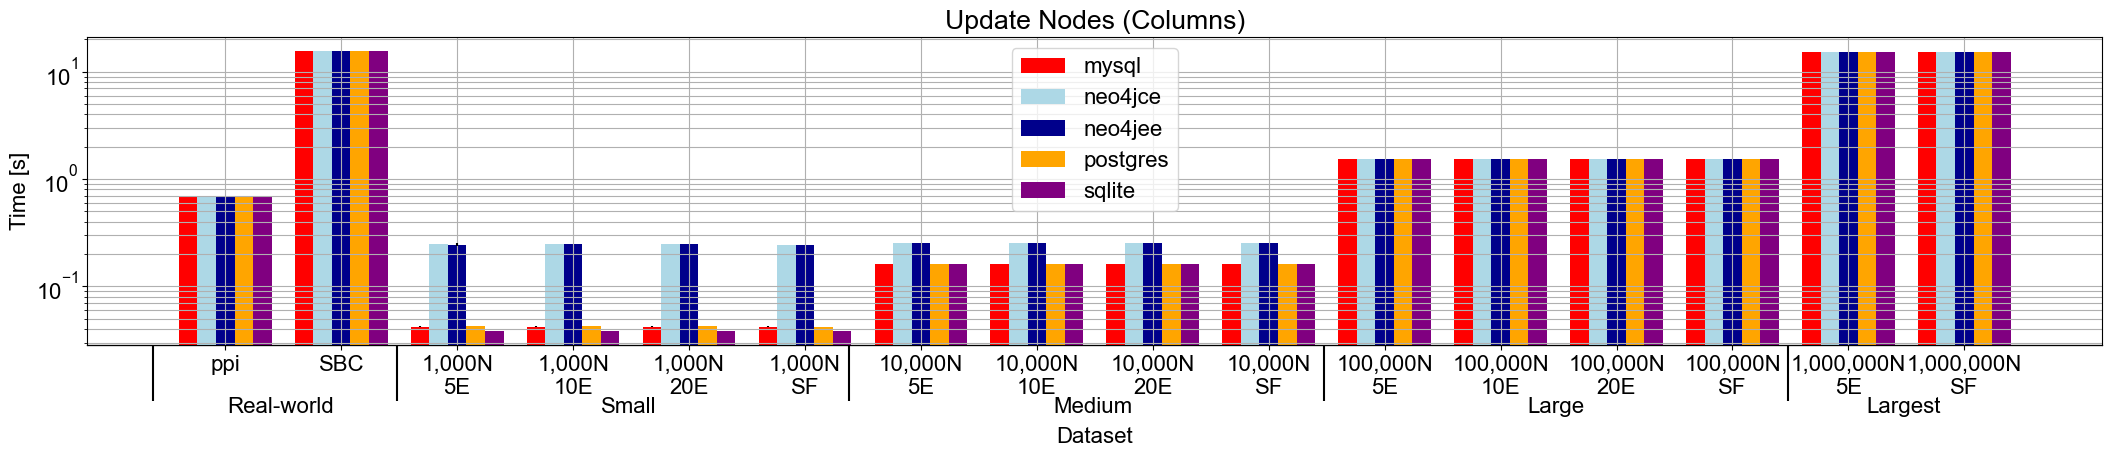

In [16]:
plot_crud_operations(header_dfs_dict, header_dfs_std_dict)

In [17]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

font = {'family': 'arial',
        'weight': 'normal',
        'size': 29}

db_colors = {
    "neo4jce": "lightblue",
    "neo4jee": "darkblue",
    "postgres": "orange",
    "mysql": "red",
    "in_mem": "black",
    "sqlite": "purple"
}

matplotlib.rc('font', **font)

def plot_crud_operations(header_dfs_dict, header_dfs_std_dict, filter_key="col", read_plot = True):
    # Collect all valid keys
    valid_keys = [key for key in header_dfs_dict if "in_mem" not in key]
    if read_plot:
        valid_keys = list(filter(lambda key: "read" in key, valid_keys))
    if not read_plot:
        valid_keys = list(filter(lambda key: "read" not in key, valid_keys))
    n_subplots = len(valid_keys)
    
    # Create vertical subplots (n rows, 1 column)
    height = 7.6 if read_plot else 8.7
    fig, axes = plt.subplots(n_subplots, 1, figsize=(30, height * n_subplots))
    if n_subplots == 1:  # Ensure axes is always iterable
        axes = [axes]
    
    legend_entries = {}  # Dictionary to track unique legend entries
    db_label_dict = {
        "mysql": "MySQL",
        "postgres": "PostgreSQL",
        "neo4j": "Neo4j",
        "in mem": "In-memory",
        "sqlite": "SQLite"
    }
    
    for ax_idx, (ax, key) in enumerate(zip(axes, valid_keys)):
        df = header_dfs_dict[key]
        df_std = header_dfs_std_dict[key]
        df = sort_and_filter_df(df, filter_key)
        df_std = sort_and_filter_df(df_std, filter_key)        
        
        num_cols = len(df.columns)
        x = np.arange(len(df))
        width = 0.8 / num_cols

        for i, col in enumerate(df.columns):
            print(col)
            #if col == "sqlite_list_"
            color_key = list(filter(lambda k: k in col, db_colors))[0]
            color = db_colors[color_key]
            db_label = " ".join(col.split("_")[:-1])
            if db_label not in legend_entries:
                db_label = db_label_dict[db_label]
                legend_entries[db_label] = color
            ax.bar(x + i * width, df[col], width=width, color=color, yerr = df_std[col])
    
        ax.set_yscale('log')
        filter_key_title_dict = {"col": "(Columns)", "list": "(List)"}
        letter_idx = chr(ord('a') + ax_idx).title()
        title = key
        if "read" in title.lower():
            title = title.replace("_", "- subgraph depth ")
        title = title.replace("_", " ")
        ax.set_title(f"{letter_idx}) {title.title()} {filter_key_title_dict[filter_key]}")
        ax.set_xticks(x + width * (num_cols / 2 - 0.5))
        
        def process_dataset_label(label: str):
            return label.replace("nodes", "N\n").replace("edges", "E")\
                        .replace("scale_free", "SF").replace("_", "").replace("000000", " mil.")[::-1]\
                        .replace("000", "000,")[::-1]
        dataset_label = list(map(process_dataset_label, df.index))
        ax.set_xticklabels(dataset_label)
        
        # Secondary x-axis for group labels at the bottom
        sec = ax.secondary_xaxis('bottom')
        
        # Secondary axis for long tick marks, also at the bottom
        sec2 = ax.secondary_xaxis('bottom')
        sec.set_xticks([.8, 3.8, 7.8,  11.8, 14.8], labels=['\n\nReal-world', '\n\nSmall', '\n\nMedium', '\n\nLarge', '\n\nLargest'])
        sec.tick_params('x', length=0)
        sec2 = ax.secondary_xaxis(location=0)
        sec2.set_xticks([-.3, 1.8, 5.7, 9.8, 13.8], labels=[])
        sec2.tick_params(axis='x', length=40, width=1.5)
        
        ax.grid(which="both", axis="y")
        ax.grid(which="major", axis="x")
        ax.set_ylabel("Time [s]")
        ax.set_xlim([-0.25, 14.75])
        # ax.set_xlabel("\nDataset\n")
    
    # Create a unified legend and position it closer to the subplots
    handles = [plt.Rectangle((0, 0), 1, 1, color=color, label=label)
               for label, color in legend_entries.items()]
    fig.legend(handles=handles, loc='lower center', ncol=((len(handles)+1)),
               bbox_to_anchor=(0.55, 1))
    
    # Use tight_layout and adjust bottom margin to reduce the gap between the last subplot and the legend
    plt.tight_layout(h_pad = 1.5)
    plt.subplots_adjust(bottom=0.18)
    
    fig_name = f"{filter_key}_read" if read_plot else f"{filter_key}_cud"
    plt.savefig(f"figures/{fig_name}", dpi=400)
    plt.show()

In [18]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

font = {'family': 'arial',
        'weight': 'normal',
        'size': 29}

db_colors = {
    "neo4jce": "lightblue",
    "neo4jee": "darkblue",
    "postgres": "orange",
    "mysql": "red",
    "in_mem": "black",
    "sqlite": "purple"
}

matplotlib.rc('font', **font)

def plot_crud_operations(header_dfs_dict, header_dfs_std_dict, filter_key="col", read_plot = True):
    # Collect all valid keys
    valid_keys = [key for key in header_dfs_dict if "in_mem" not in key]
    if read_plot:
        valid_keys = list(filter(lambda key: "read" in key, valid_keys))
    if not read_plot:
        valid_keys = list(filter(lambda key: "read" not in key, valid_keys))
    n_subplots = len(valid_keys)
    
    # Create vertical subplots (n rows, 1 column)
    height = 7.6 if read_plot else 8.7
    fig, axes = plt.subplots(n_subplots, 1, figsize=(30, height * n_subplots))
    if n_subplots == 1:  # Ensure axes is always iterable
        axes = [axes]
    
    legend_entries = {}  # Dictionary to track unique legend entries
    db_label_dict = {
        "mysql": "MySQL",
        "postgres": "PostgreSQL",
        "neo4jce": "Neo4j-Community Edition",
        "neo4jee": "Neo4j-Enterprise Edition",
        "in mem": "In-memory",
        "sqlite": "SQLite"
    }
    
    for ax_idx, (ax, key) in enumerate(zip(axes, valid_keys)):
        df = header_dfs_dict[key]
        df_std = header_dfs_std_dict[key]
        df = sort_and_filter_df(df, filter_key)
        df_std = sort_and_filter_df(df_std, filter_key)        
        
        x = np.arange(len(df))
        for i, col in enumerate(df.columns):
            #if col == "sqlite_list_"
            color_key = list(filter(lambda k: k in col, db_colors))[0]
            color = db_colors[color_key]
            db_label = " ".join(col.split("_")[:-1])
            if db_label not in legend_entries:
                db_label = db_label_dict[db_label]
                legend_entries[db_label] = color
            ax.errorbar(
                x, 
                df[col], 
                yerr=df_std[col], 
                label=db_label, 
                color=color,
                marker="o",
                linestyle='--', # Using a dashed line for clarity
                capsize=7,
                linewidth=4,
                elinewidth=3,
                markersize=8
            )
    
        ax.set_yscale('log')
        filter_key_title_dict = {"col": "(Columns)", "list": "(List)"}
        letter_idx = chr(ord('a') + ax_idx).title()
        title = key
        if "read" in title.lower():
            title = title.replace("_", "- subgraph depth ")
        title = title.replace("_", " ")
        ax.set_title(f"{letter_idx}) {title.title()} {filter_key_title_dict[filter_key]}")
        ax.set_xticks(x)
        
        def process_dataset_label(label: str):
            return label.replace("nodes", "N\n").replace("edges", "E")\
                        .replace("scale_free", "SF").replace("_", "").replace("000000", " mil.")[::-1]\
                        .replace("000", "000,")[::-1]
        dataset_label = list(map(process_dataset_label, df.index))
        ax.set_xticklabels(dataset_label)
        
        # Secondary x-axis for group labels at the bottom
        sec = ax.secondary_xaxis('bottom')
        sec.set_xticks([.8, 3.8, 7.8,  11.8, 14.8], labels=['\n\nReal-world', '\n\nSmall', '\n\nMedium', '\n\nLarge', '\n\nLargest'])
        sec.tick_params(axis='x', length=0)
        
        # Secondary axis for long tick marks, also at the bottom
        sec2 = ax.secondary_xaxis('bottom')
        sec2.set_xticks([-.25, 1.6, 5.45, 9.51, 13.55], labels=[])
        sec2.tick_params(axis='x', length=40, width=1.5)
        
        ax.grid(which="both", axis="y")
        ax.grid(which="major", axis="x")
        ax.set_ylabel("Time [s]")
        ax.set_xlim([-0.25, 15.25])
        # ax.set_xlabel("\nDataset\n")
    
    # Create a unified legend and position it closer to the subplots
    handles = [plt.Rectangle((0, 0), 1, 1, color=color, label=label)
               for label, color in legend_entries.items()]
    fig.legend(handles=handles, loc='lower center', ncol=((len(handles)+1)),
               bbox_to_anchor=(0.55, 1))
    
    # Use tight_layout and adjust bottom margin to reduce the gap between the last subplot and the legend
    plt.tight_layout(h_pad = 1.5)
    plt.subplots_adjust(bottom=0.18)
    
    fig_name = f"{filter_key}_read" if read_plot else f"{filter_key}_cud"
    plt.savefig(f"figures/{fig_name}", dpi=400)
    plt.show()

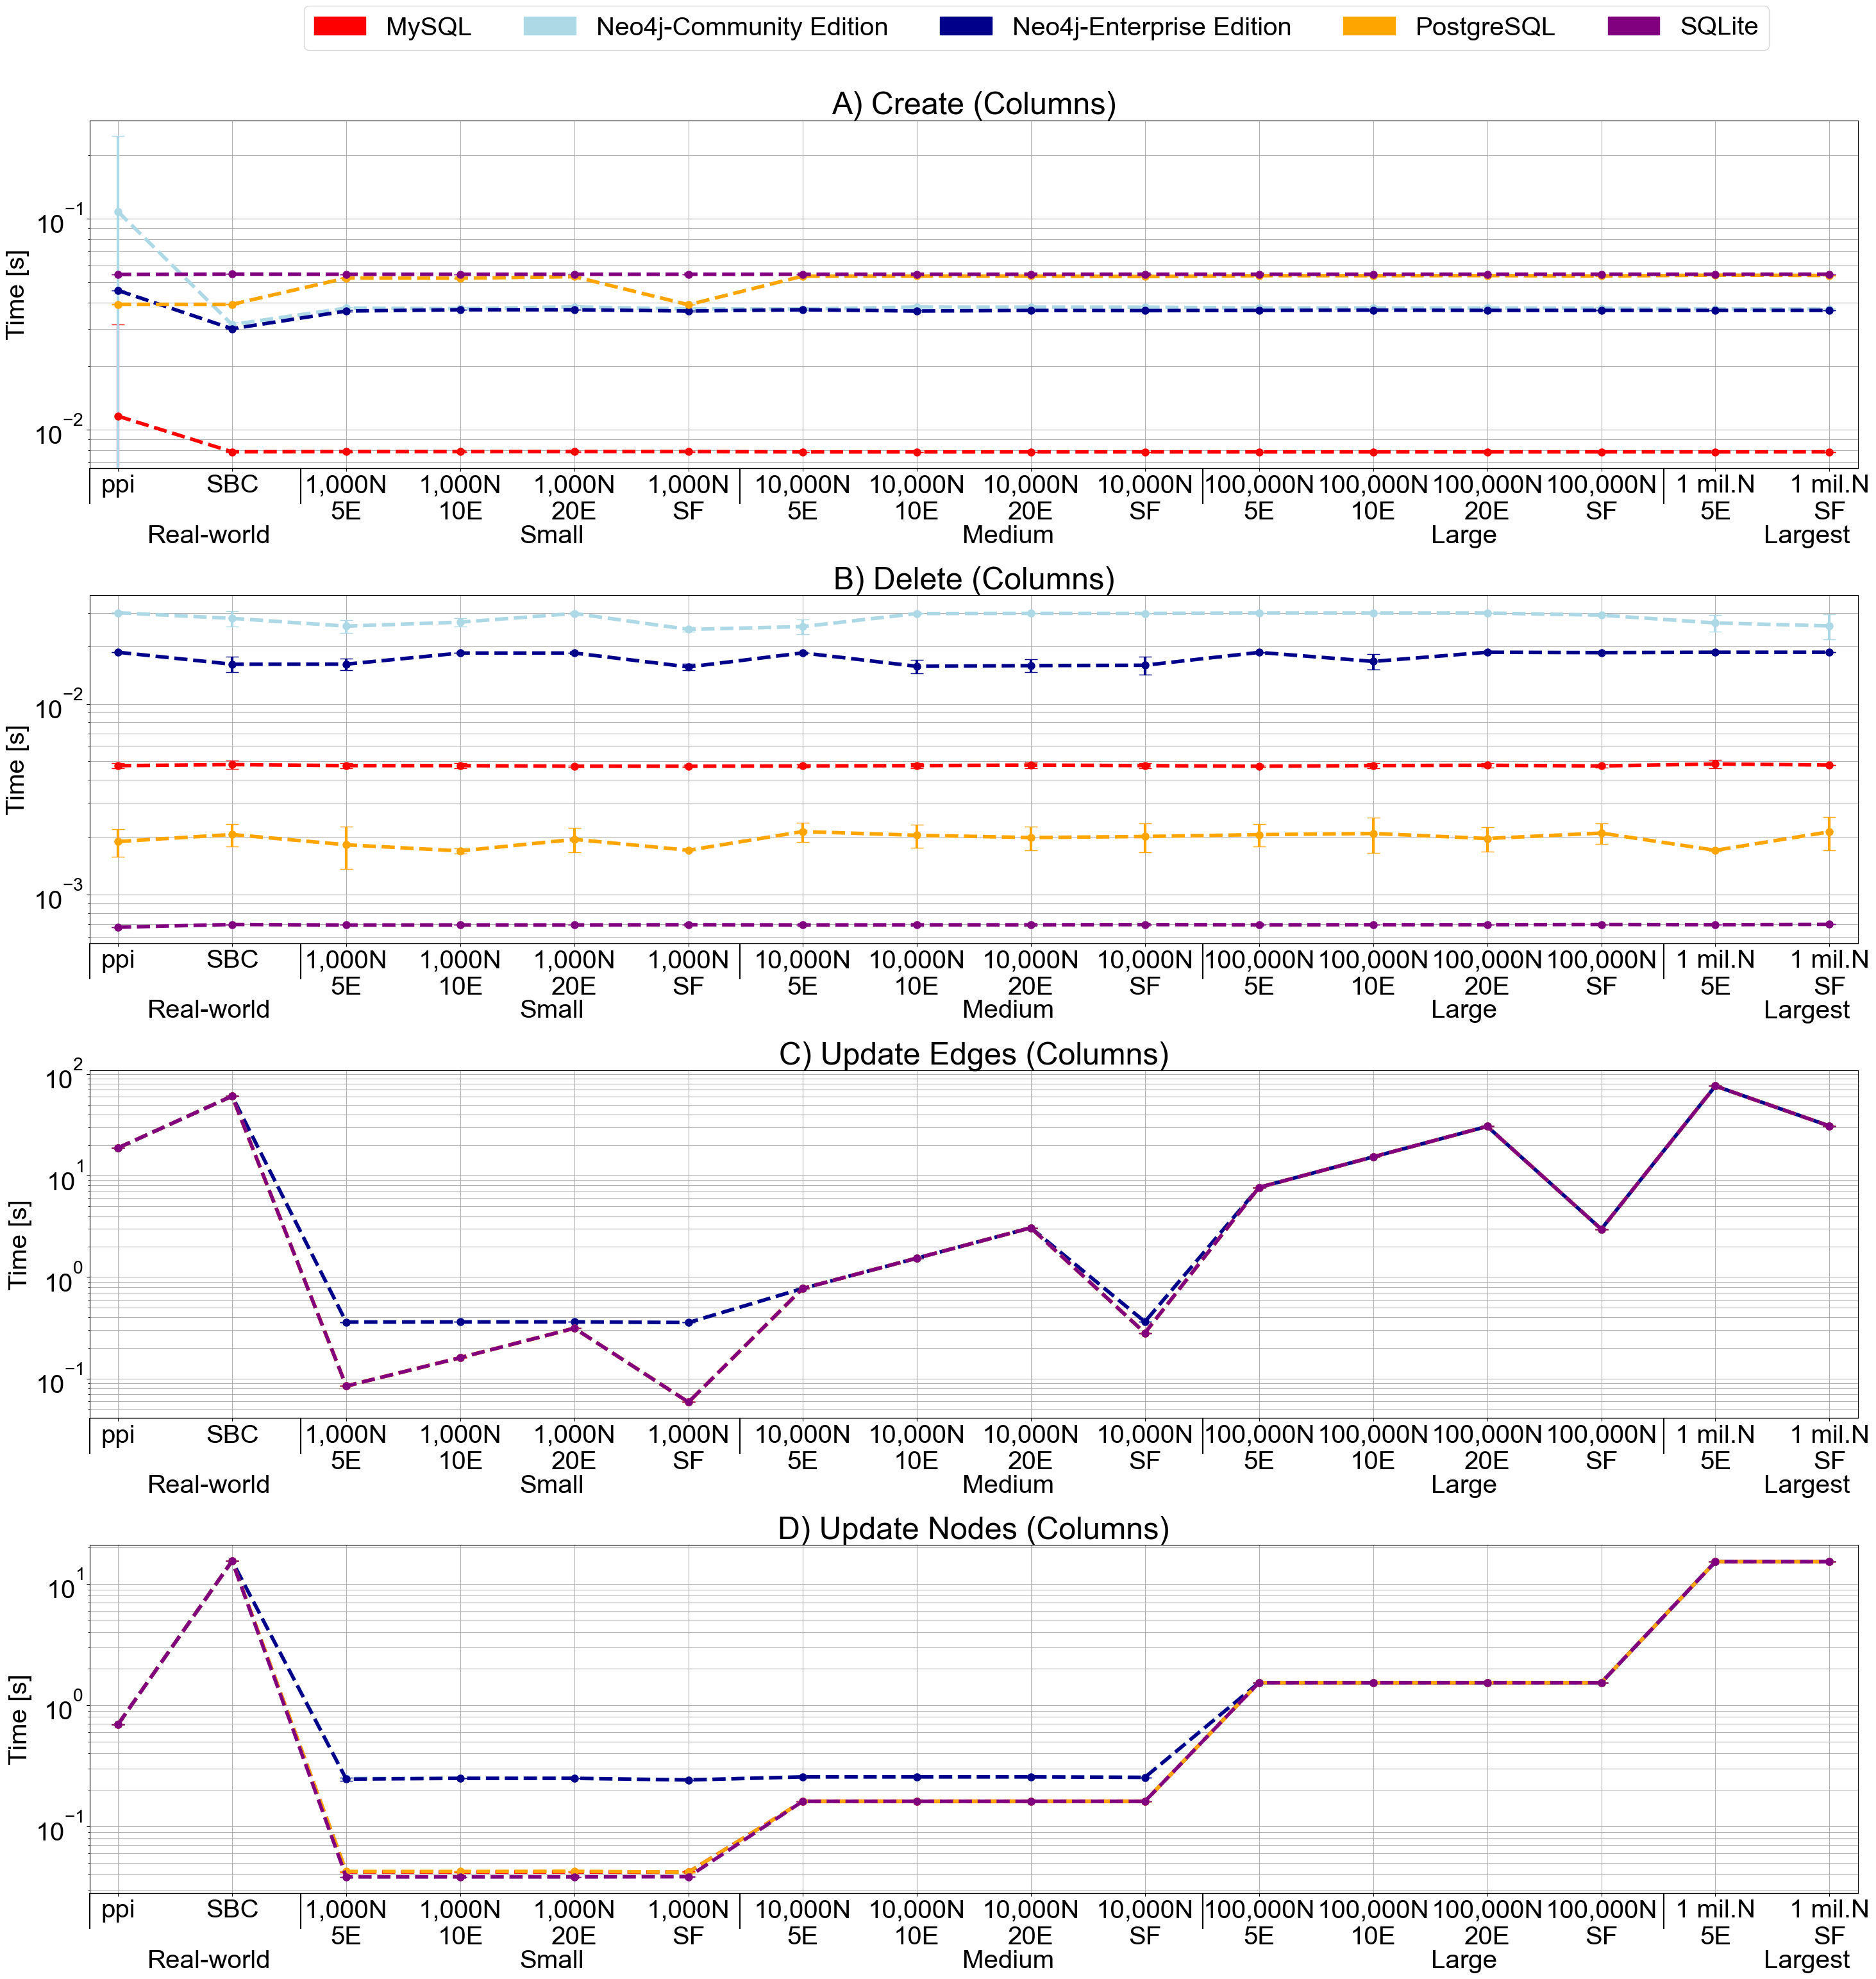

In [19]:
plot_crud_operations(header_dfs_dict, header_dfs_std_dict, filter_key = "col", read_plot=False)

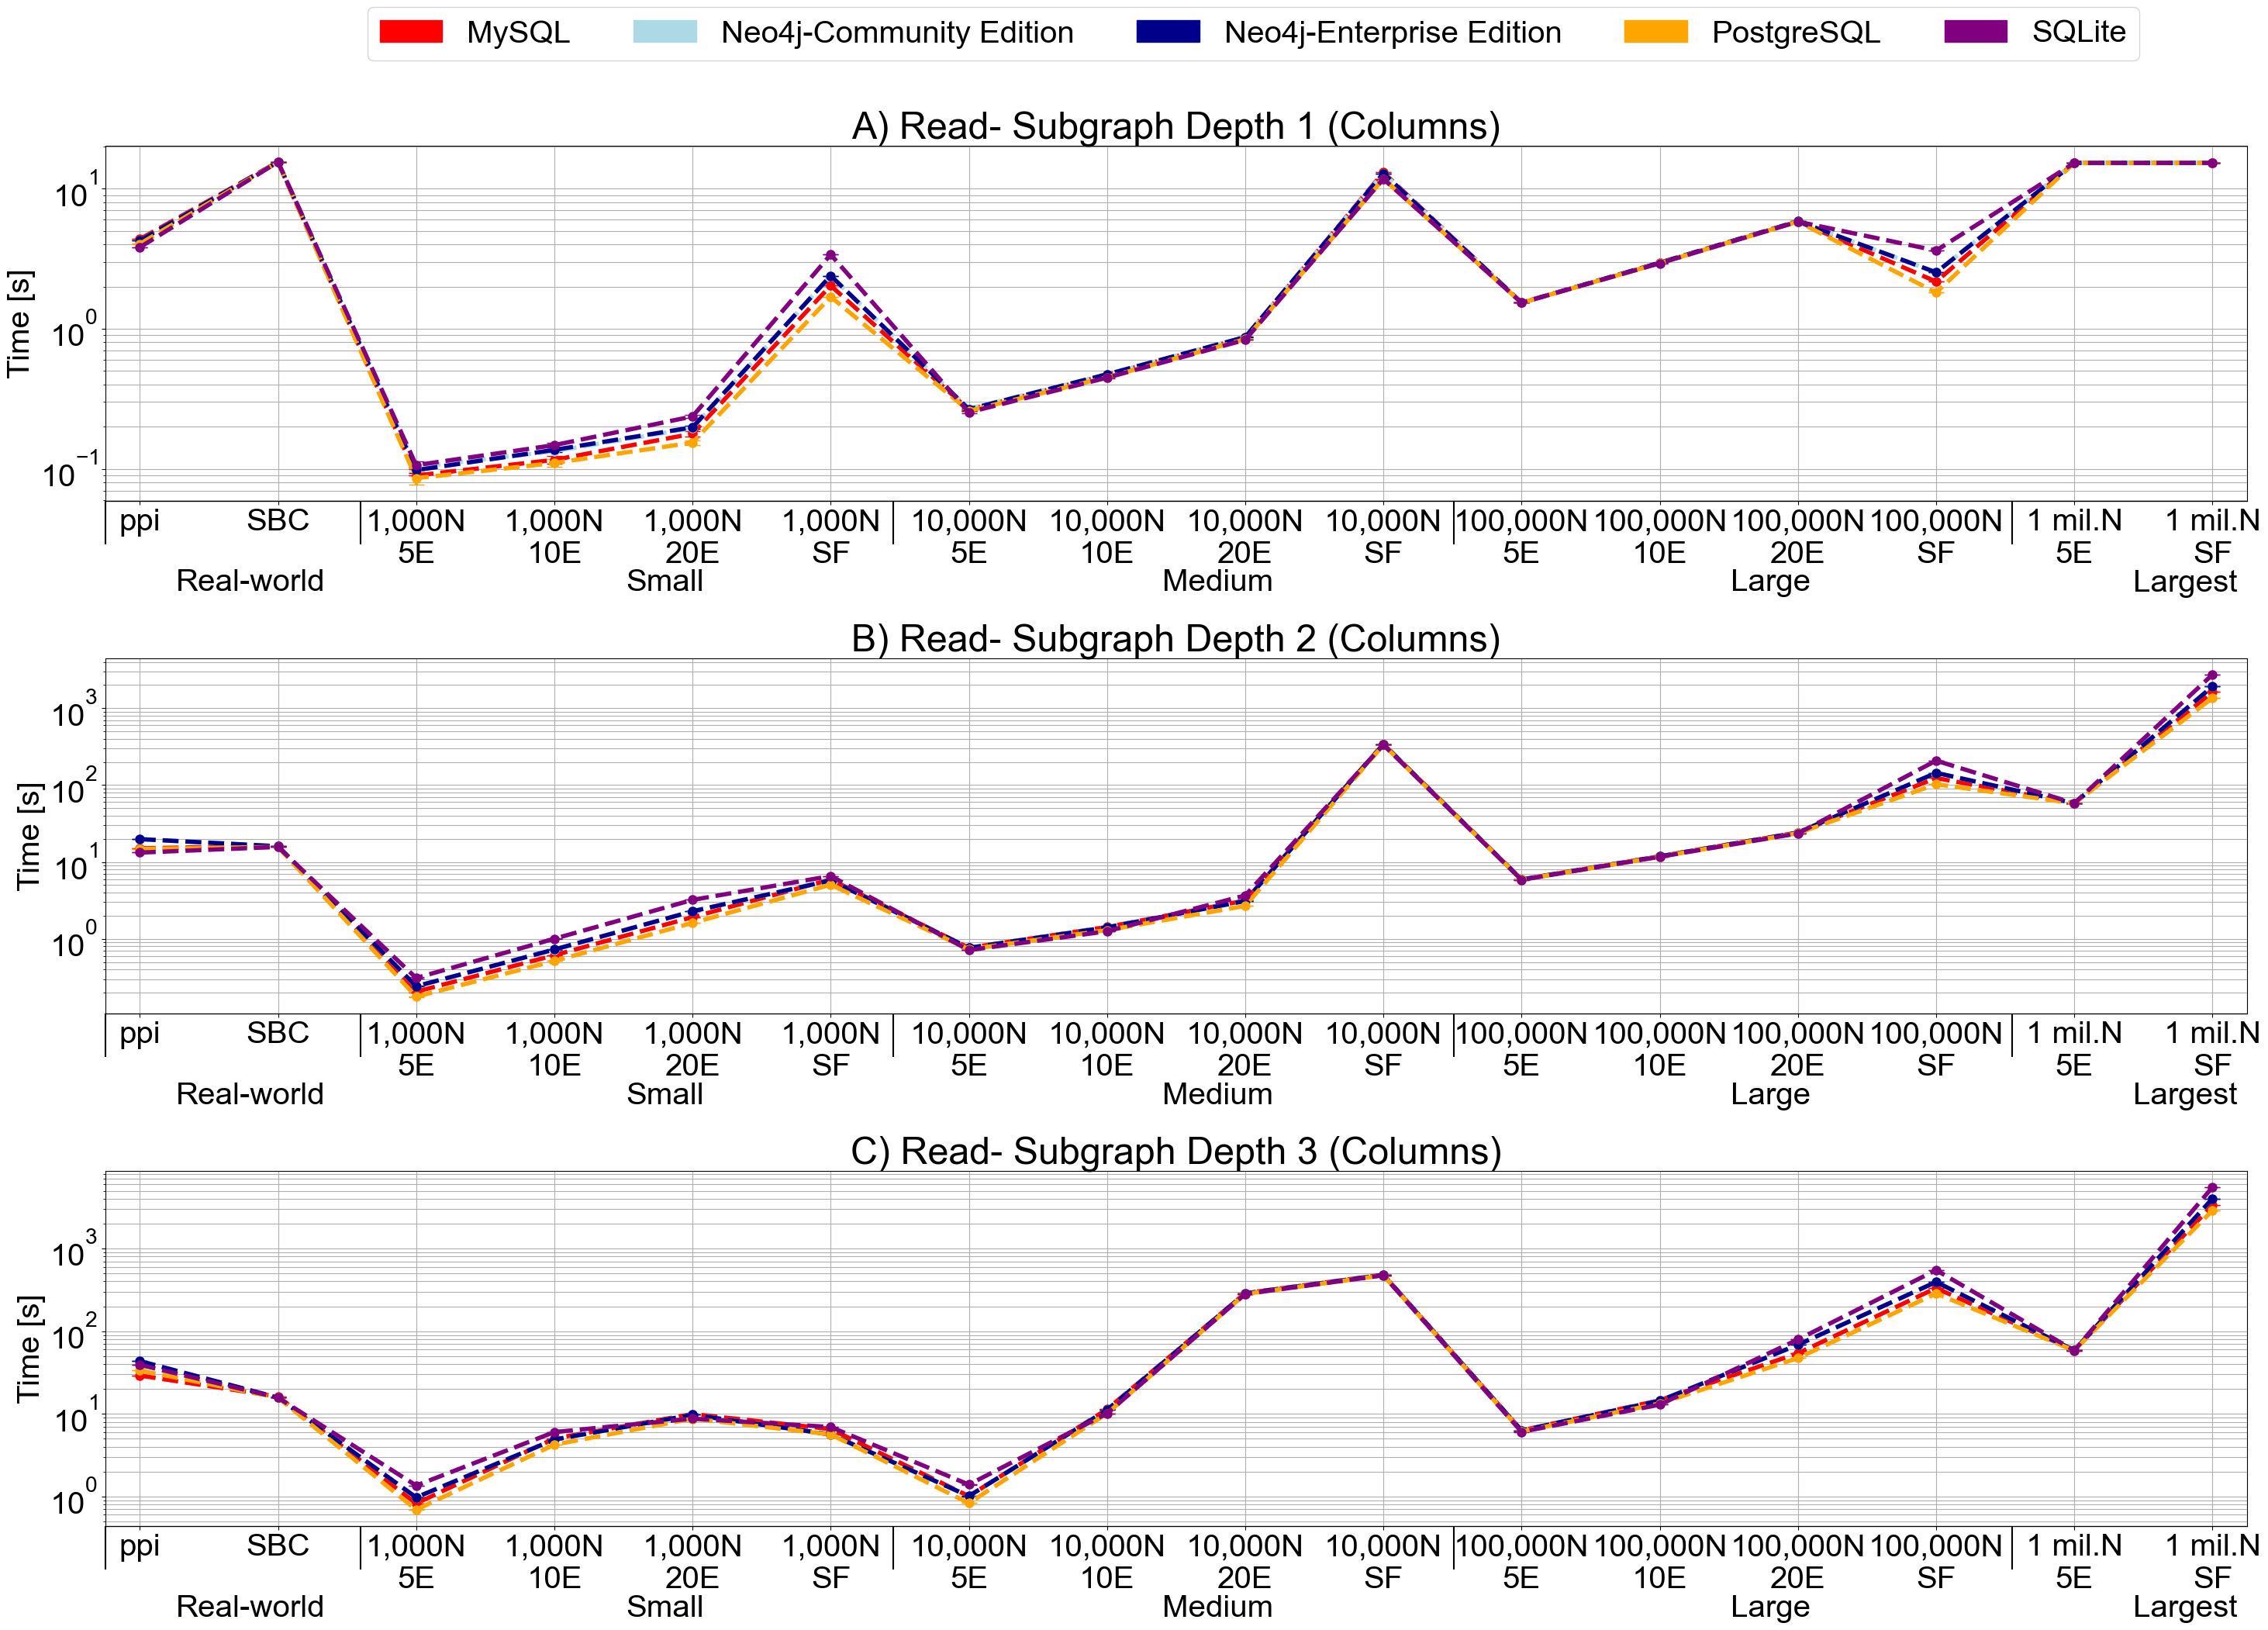

In [20]:
plot_crud_operations(header_dfs_dict, header_dfs_std_dict, filter_key = "col", read_plot=True)

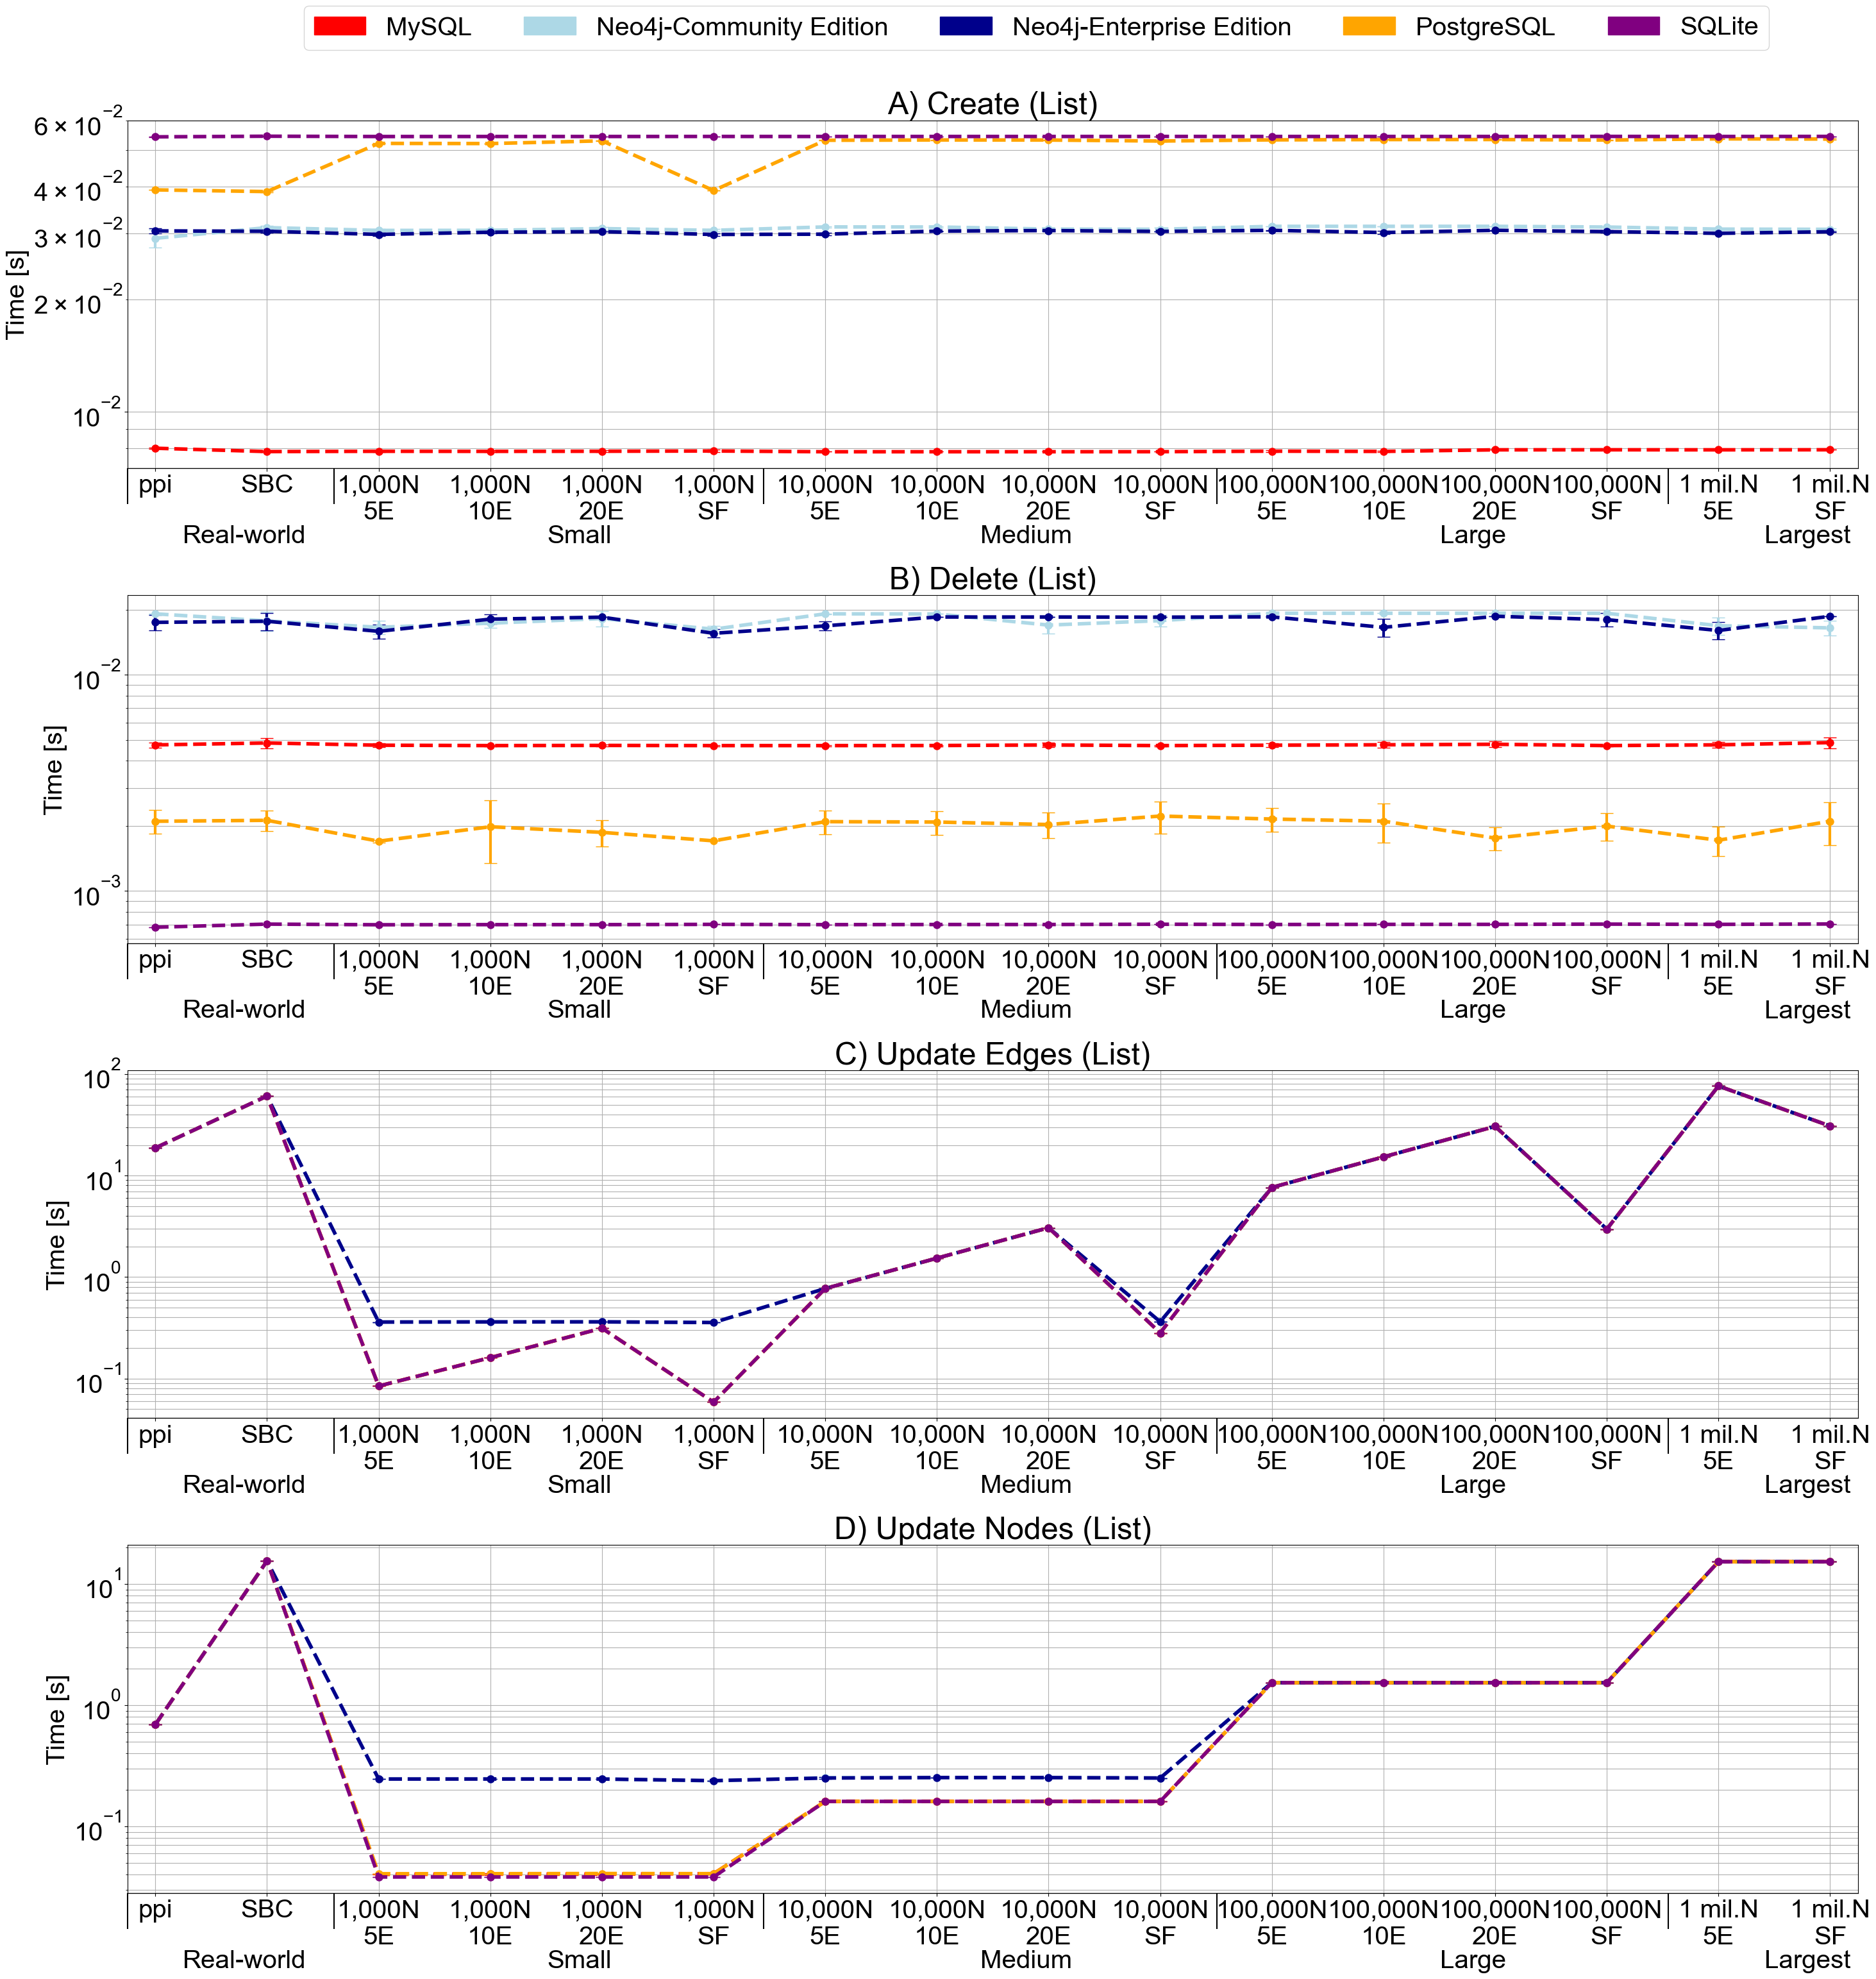

In [21]:
plot_crud_operations(header_dfs_dict, header_dfs_std_dict, "list", False)

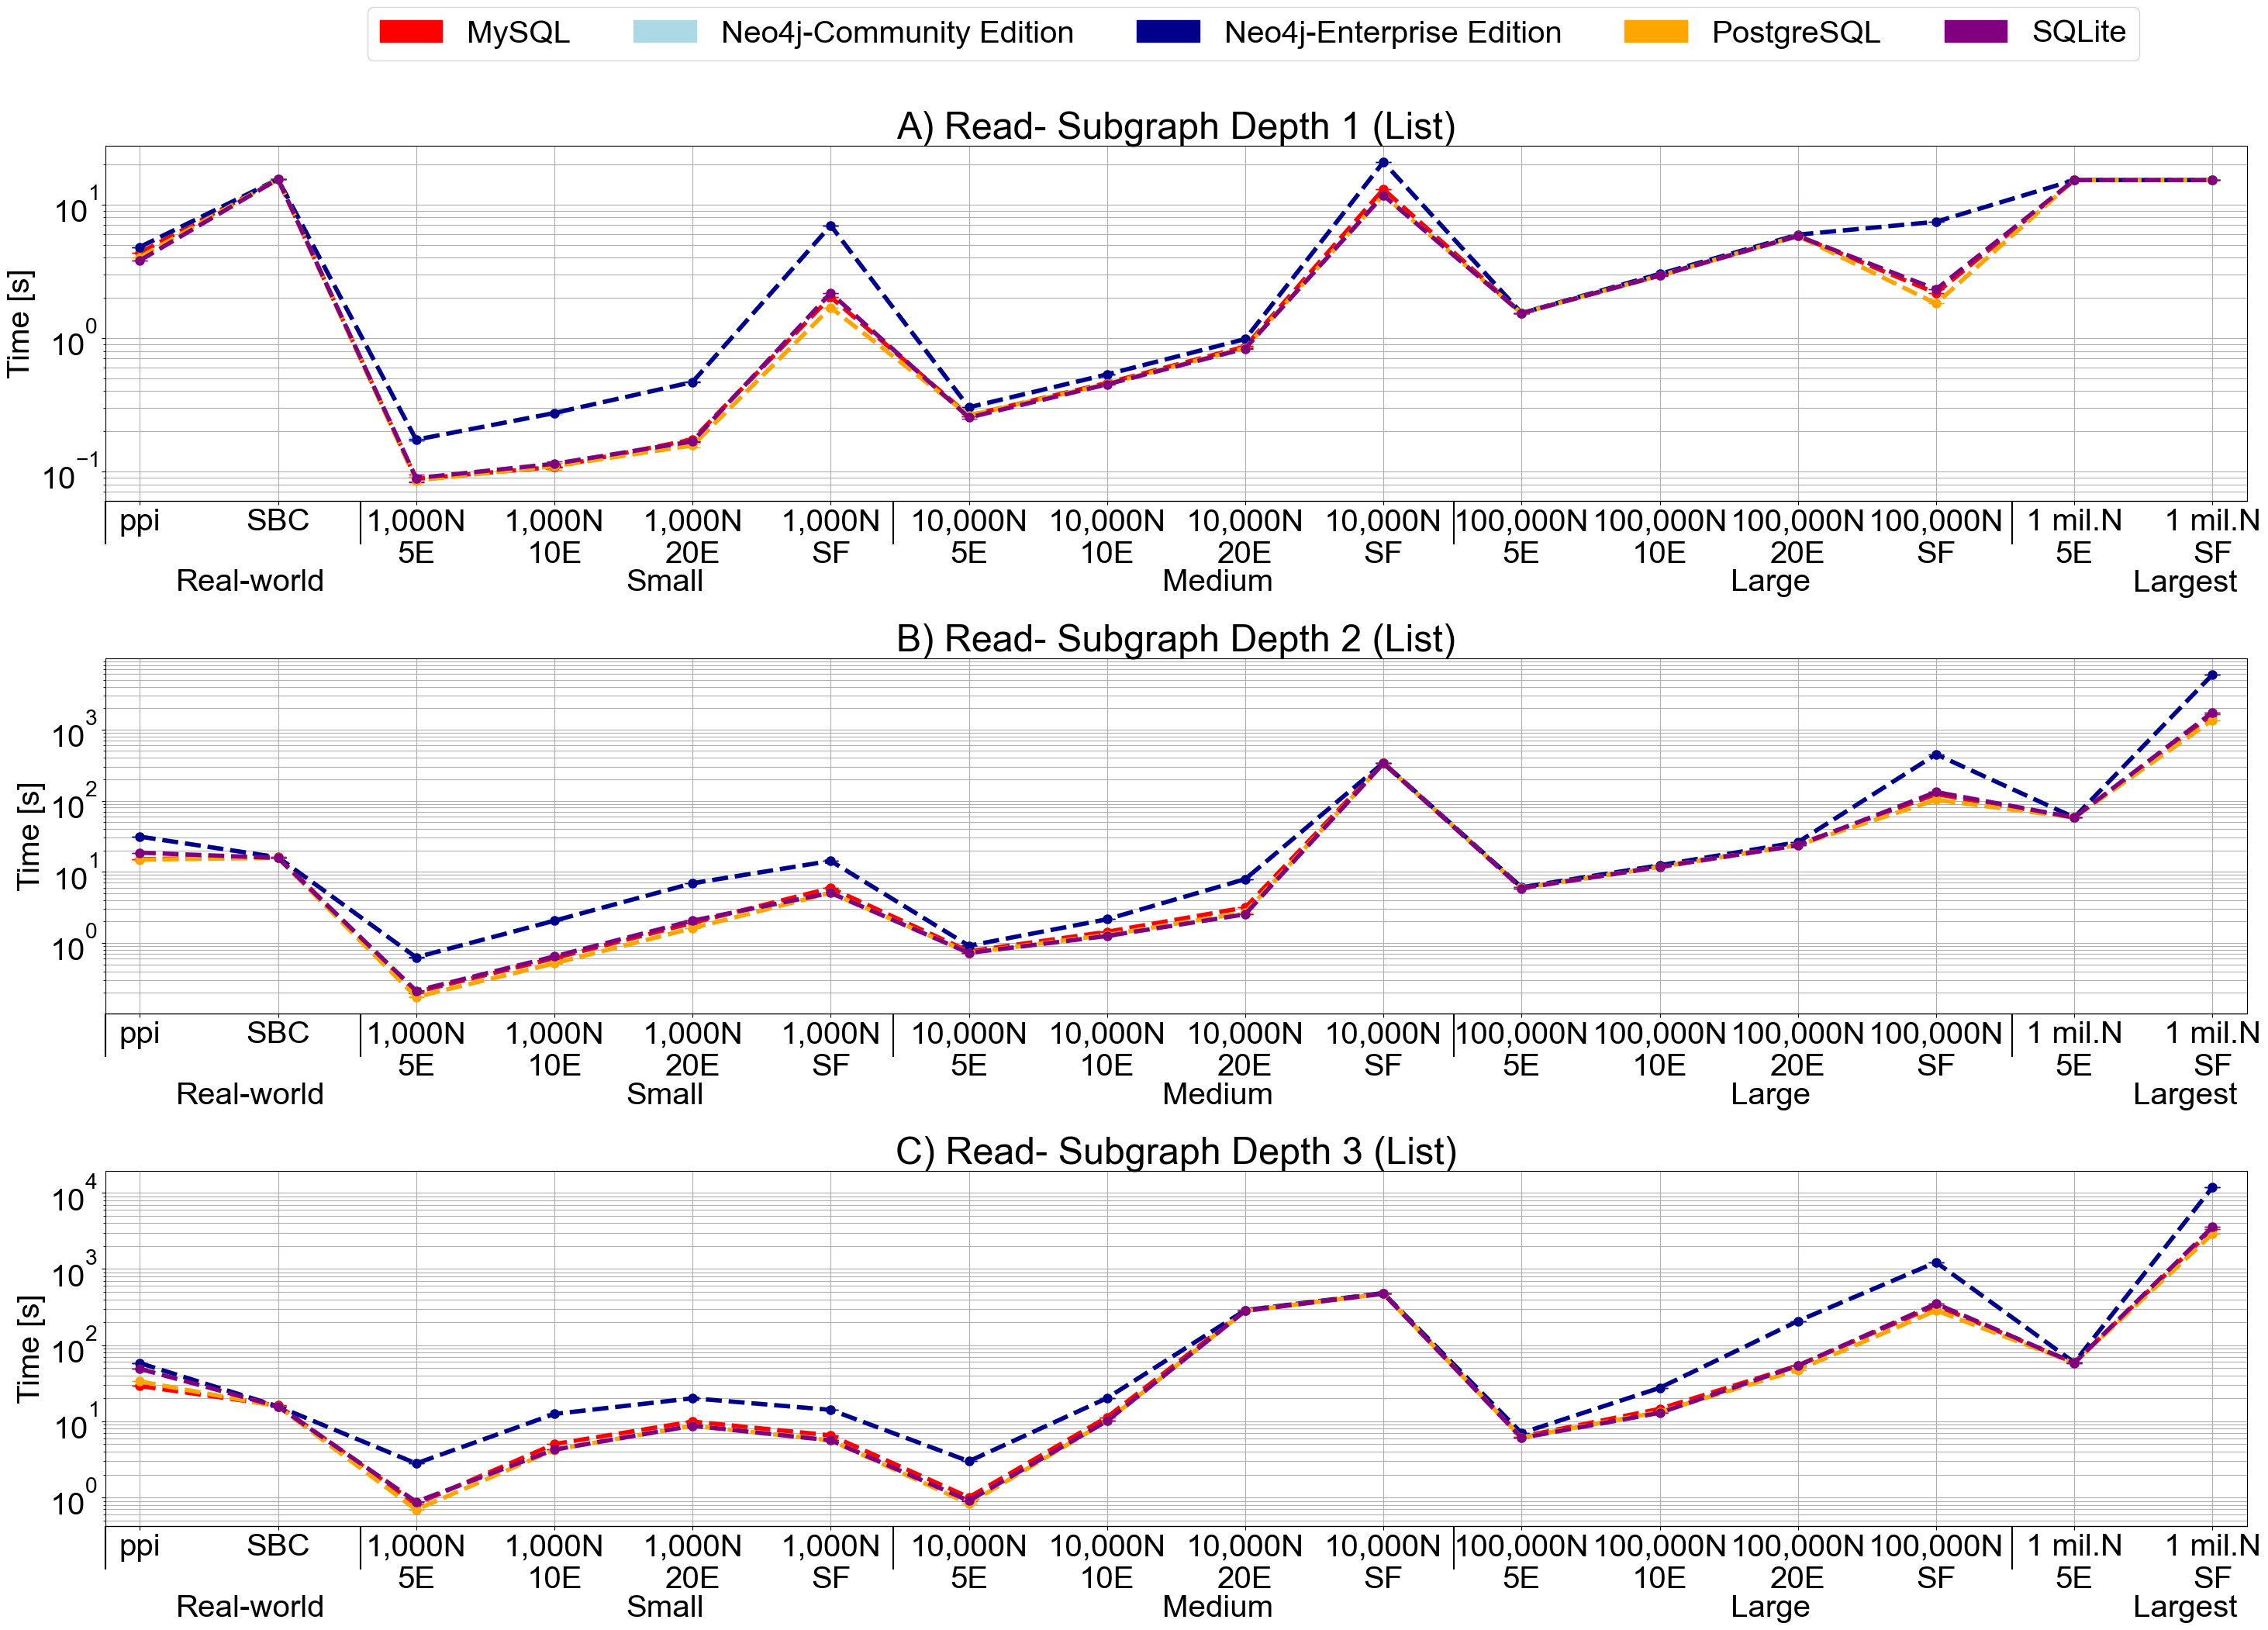

In [22]:
plot_crud_operations(header_dfs_dict, header_dfs_std_dict, "list", True)

In [23]:
header_dfs_dict["create"].max().sort_values()

mysql_list       0.008003
mysql_col        0.011570
neo4jee_list     0.030568
neo4jce_list     0.031329
neo4jee_col      0.045596
postgres_list    0.053651
postgres_col     0.053857
sqlite_col       0.054511
sqlite_list      0.054526
neo4jce_col      0.107755
dtype: float64

In [24]:
for key in header_dfs_dict:
    print(key)
    print(header_dfs_dict[key].max().sort_values())

create
mysql_list       0.008003
mysql_col        0.011570
neo4jee_list     0.030568
neo4jce_list     0.031329
neo4jee_col      0.045596
postgres_list    0.053651
postgres_col     0.053857
sqlite_col       0.054511
sqlite_list      0.054526
neo4jce_col      0.107755
dtype: float64
delete
sqlite_col       0.000697
sqlite_list      0.000704
postgres_col     0.002137
postgres_list    0.002221
mysql_col        0.004836
mysql_list       0.004857
neo4jee_list     0.018643
neo4jee_col      0.018643
neo4jce_list     0.019253
neo4jce_col      0.030027
dtype: float64
read_1
postgres_list    15.496849
neo4jee_col      15.496849
sqlite_col       15.496849
postgres_col     15.496849
sqlite_list      15.496849
mysql_col        15.496849
neo4jce_col      15.496849
mysql_list       15.496849
neo4jce_list     20.851440
neo4jee_list     20.851974
dtype: float64
read_2
postgres_list    1358.001365
postgres_col     1358.003492
mysql_list       1624.530391
mysql_col        1624.534832
sqlite_list      1738

In [25]:
import seaborn as sns
sns.set(font_scale=1.2)
def process_dataset_label(label: str):
    return label.replace("nodes", "N ").replace("edges", "E")\
                .replace("scale_free", "SF").replace("_", "").replace("000000", " Mio.")[::-1]\
                .replace("000", "000,")[::-1]

def plot_heatmap(keys):
    fig, axs = plt.subplots(len(keys), 1, sharex=False, figsize = (13, int(2.5*len(keys))))
    filtered_header_dfs_dict = {key: header_dfs_dict[key] for key in keys}
    for i, key in enumerate(filtered_header_dfs_dict):
        
        df = header_dfs_dict[key]
        in_mem_cols = list(filter(lambda db: "mem" in db, df.columns))
        for col in in_mem_cols:
            df.pop(col)        
        datasets = list(map(process_dataset_label, df.index)) 
        dbs = df.columns
        min_vals = df.min(axis=1).values.reshape(-1, 1)
        max_vals = df.max(axis=1).values.reshape(-1, 1)
        normed_vals = (df.values - min_vals) / (max_vals - min_vals)
        normed_df = pd.DataFrame(data = normed_vals, columns=dbs, index = datasets)
        sorted_columns = sorted(dbs)
        df_sorted = normed_df.reindex(columns=sorted_columns)
        #fig, axs = plt.subplots()
        sns.heatmap(df_sorted, cmap="crest", linewidths=1, ax=axs[i], cbar = False)
        axs[i].set_ylabel(key.capitalize())
        axs[i].xaxis.set_ticks_position('top')
        axs[i].tick_params(axis='x')
        
        if i != 0:
            axs[i].set_xticks([])
    cbar = fig.colorbar(axs[-1].collections[0], ax=axs[-1], location='bottom', fraction=0.1, pad=0.04, orientation='horizontal')
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.03)

/tmp/ipykernel_1780076/3546284393.py:21: RuntimeWarning: invalid value encountered in divide
  normed_vals = (df.values - min_vals) / (max_vals - min_vals)


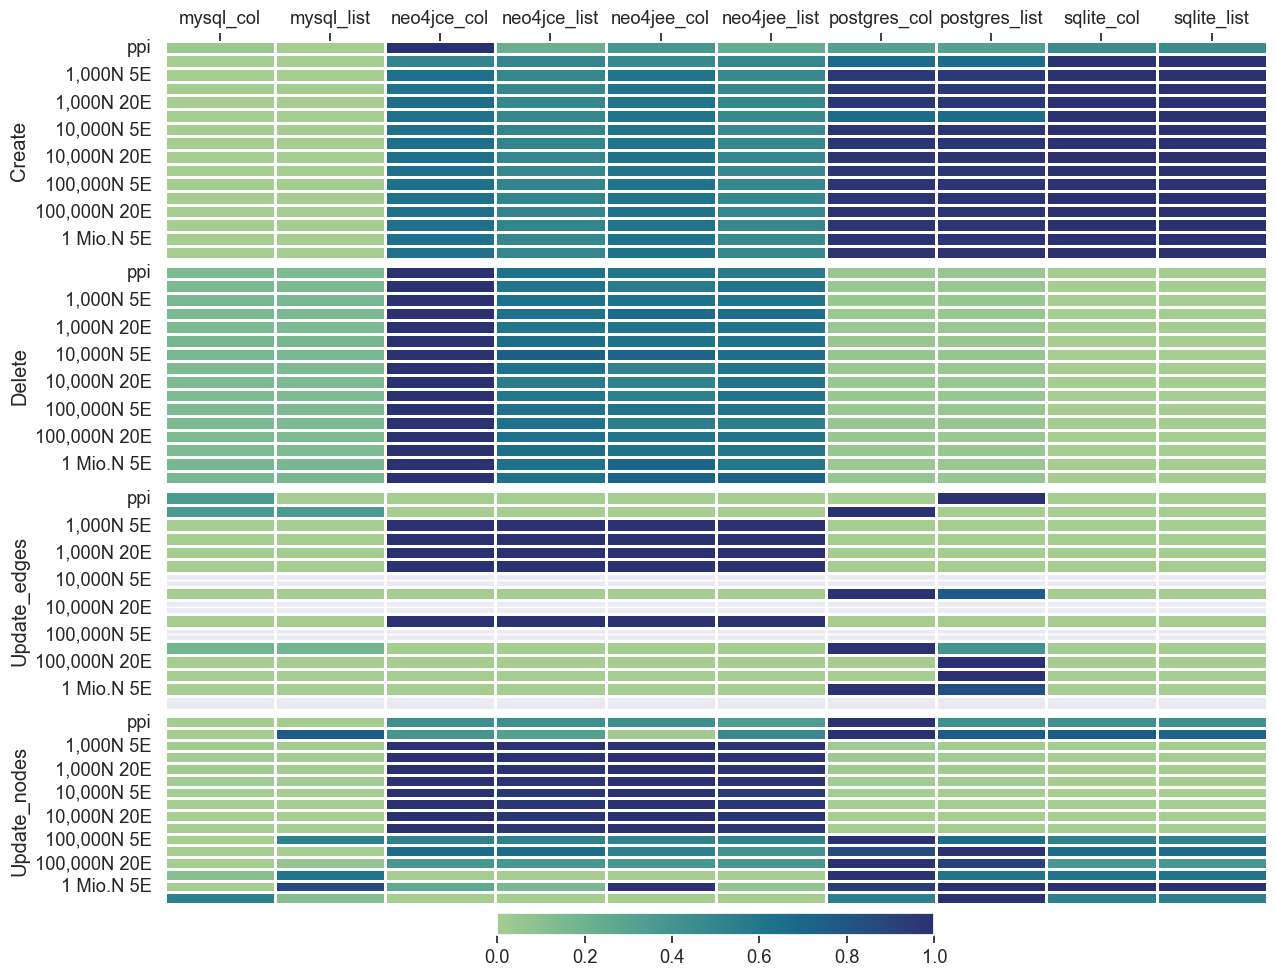

In [26]:
read_keys = list(filter(lambda key: "read" in key and "mem" not in key, list(header_dfs_dict.keys())))
cud_keys = list(filter(lambda key: "read" not in key, list(header_dfs_dict.keys())))
plot_heatmap(cud_keys)

/tmp/ipykernel_1780076/3546284393.py:21: RuntimeWarning: invalid value encountered in divide
  normed_vals = (df.values - min_vals) / (max_vals - min_vals)


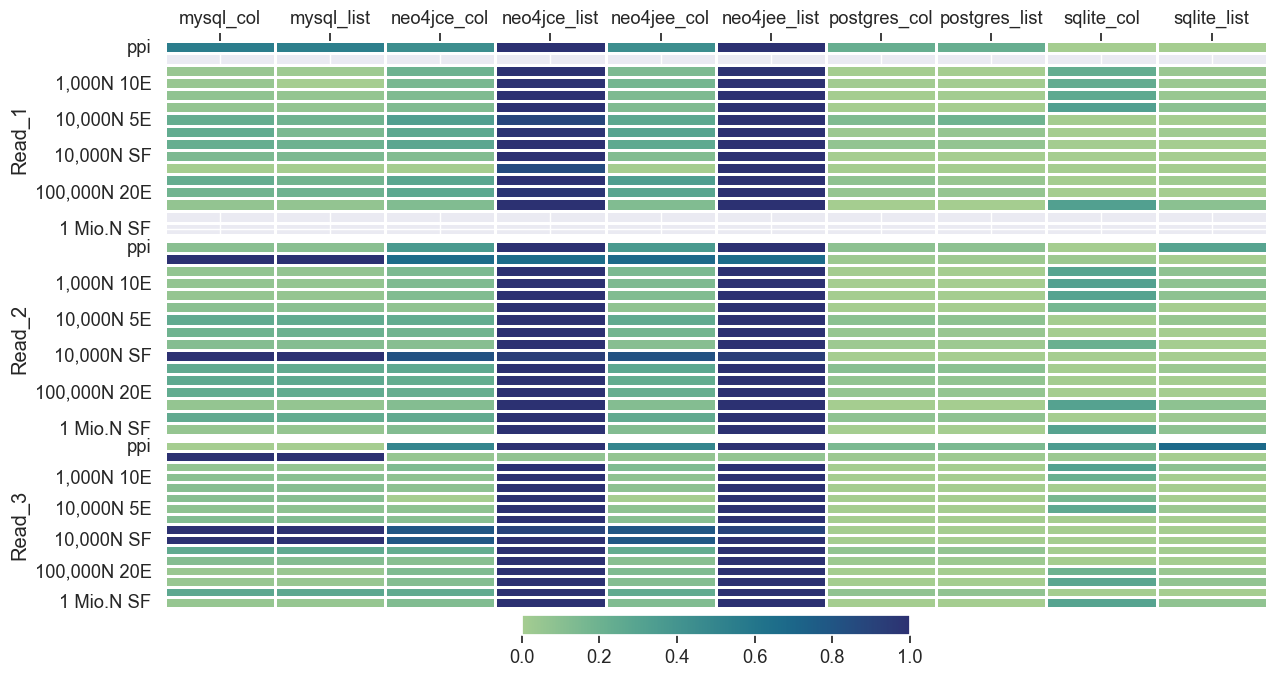

In [27]:
plot_heatmap(read_keys)

/tmp/ipykernel_1780076/3546284393.py:21: RuntimeWarning: invalid value encountered in divide
  normed_vals = (df.values - min_vals) / (max_vals - min_vals)
/tmp/ipykernel_1780076/3546284393.py:21: RuntimeWarning: invalid value encountered in divide
  normed_vals = (df.values - min_vals) / (max_vals - min_vals)


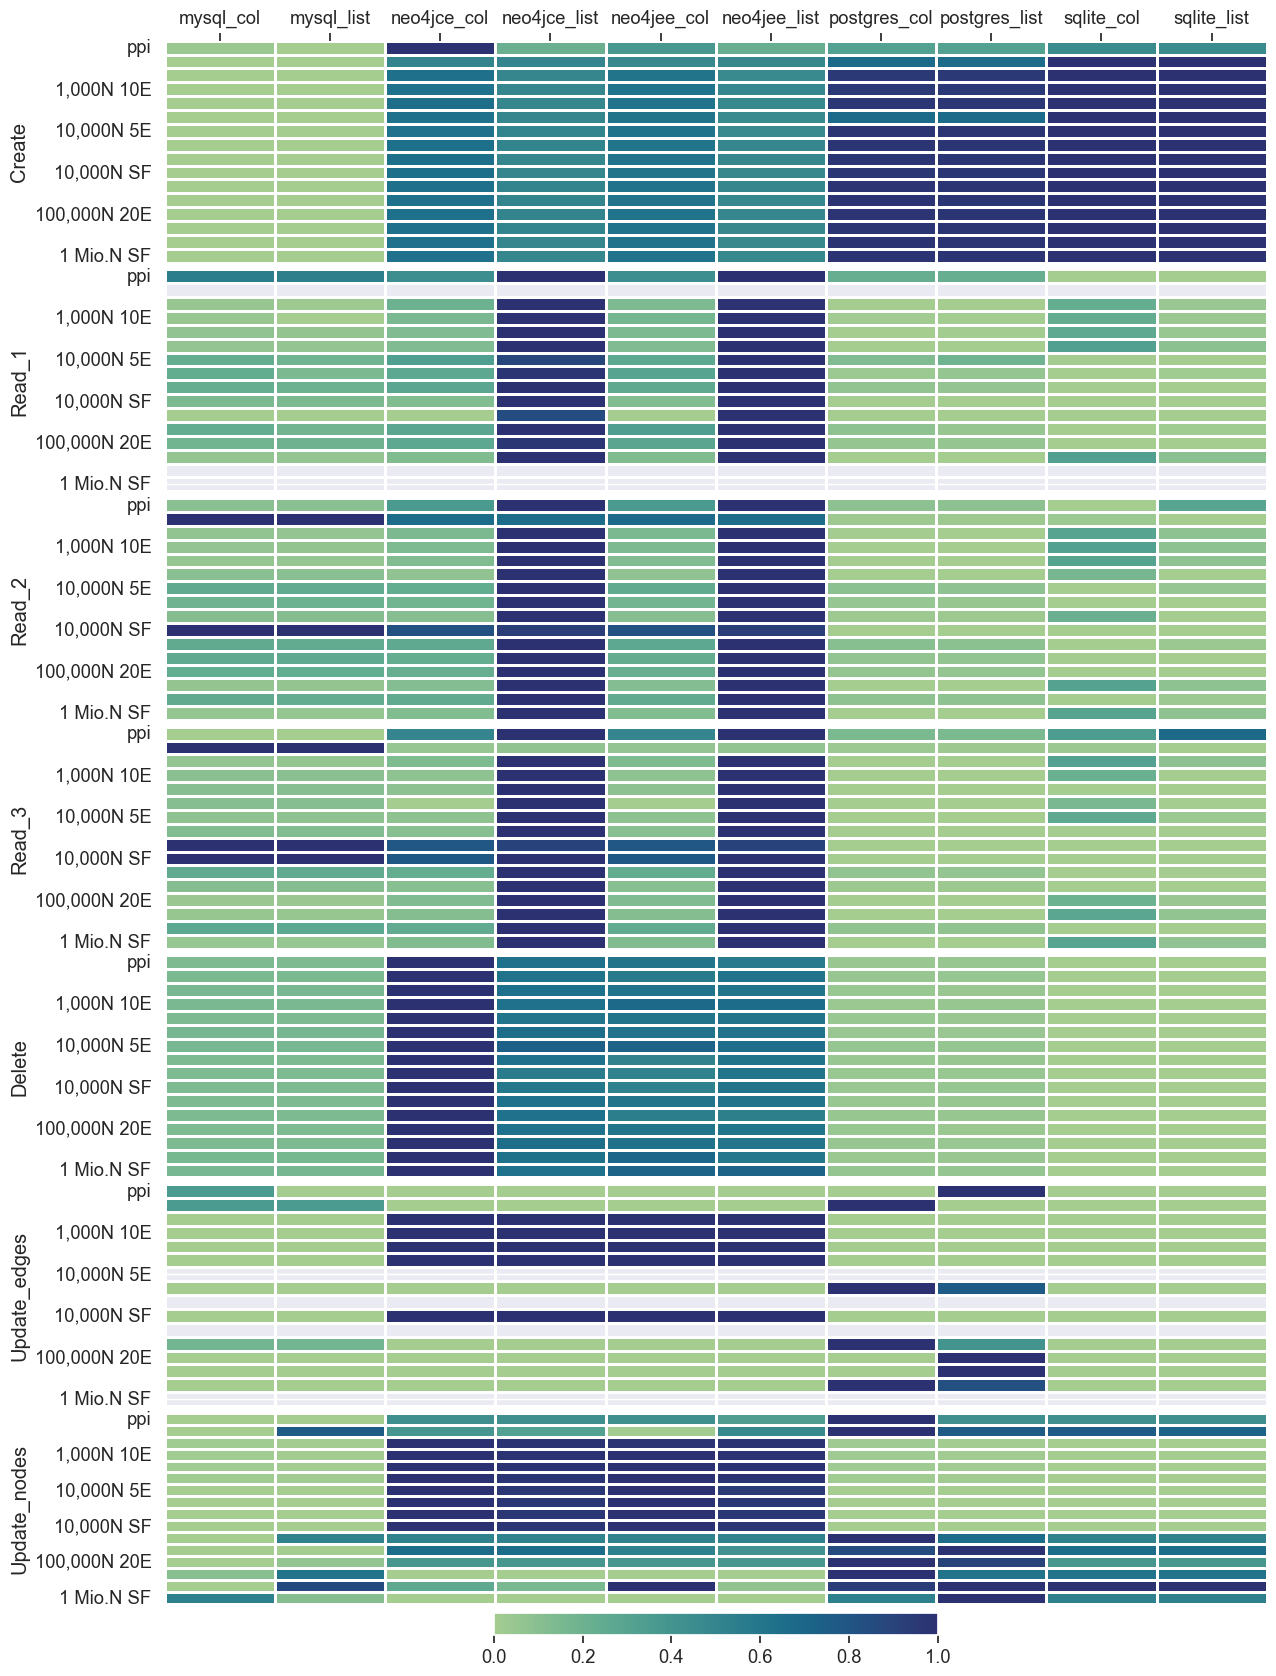

In [28]:
plot_heatmap([cud_keys[0], *read_keys, *cud_keys[1:]])